In [1]:
import pandas as pd

In [2]:
# Merging vis and lepton temperature values

vi_filename = "data/all_vis_all_cams_with_yield.xlsx"
temperature_filename = "data/lepton_temperature.xlsx"
merged_vi_temp_filename = "data/all_vi_temp_with_yield.xlsx"

vi_df = pd.read_excel(vi_filename)
temperature_df = pd.read_excel(temperature_filename)

combined_vi_and_temp_df = pd.DataFrame()

vi_df['date'] = pd.to_datetime(vi_df['date'], format='%Y-%m-%d')
temperature_df['date'] = pd.to_datetime(temperature_df['date'], format='%Y-%m-%d')
temperature_df = temperature_df.rename(columns={
    "plot": "plot_location"
})

temperature_df['plot_location'] = temperature_df['plot_location'].str.replace('_', '-', regex=False)

merged_df = vi_df.merge(
    temperature_df,
    on=["cam_no", "plot_location", "date"],
    how="left",
)

print(merged_df.head())
print(merged_df.shape)

merged_df.to_excel(merged_vi_temp_filename, index=False)


  plot_id       date  hour  plot_no treatment  cam_no plot_location  \
0     1_d 2024-06-25    13        1         d       5  right-middle   
1     1_d 2024-06-28    10        1         d       5  right-middle   
2     1_d 2024-06-27    15        1         d       5  right-middle   
3     1_d 2024-06-30    15        1         d       5  right-middle   
4     1_d 2024-06-27    10        1         d       5  right-middle   

                           filename  ndvi_noir_rgb_method  \
0  date_25-6-2024_13.0.11_1.png.tif              0.023891   
1  date_28-6-2024_10.0.10_1.png.tif              0.004482   
2  date_27-6-2024_15.0.10_1.png.tif              0.030761   
3  date_30-6-2024_15.0.10_1.png.tif              0.017231   
4  date_27-6-2024_10.0.10_1.png.tif              0.016498   

   ndvi_predicted_nir_method  ...   GYLD    TW  PROT      BARCODE  GYLD_kg_m3  \
0                   0.044178  ...  14505  60.8  13.4  2024 8 41 1      1.4505   
1                  -0.077855  ...  14505  60

In [4]:
df = pd.read_excel(merged_vi_temp_filename)
print(df.shape)


(7998, 40)


In [71]:

vi_features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method', 'rdvi_noir_rgb_method', 'savi_noir_rgb_method', 'sr_noir_rgb_method','evi_noir_rgb_method', 'cigreen_noir_rgb_method' ]
features = vi_features + ['lepton_mean_temp', 'lepton_min_temp', 'lepton_max_temp']
output_variable = 'GYLD_kg_m3'

In [72]:

df_hour13 = df[(df['hour'] > 11) & (df['hour'] < 14)].copy()
df_hour10 = df[df['hour'] < 12].copy()

# Filter yield greater than 0
df_hour13 = df_hour13[(df_hour13[output_variable] > 0)]
df_hour10 = df_hour10[(df_hour10[output_variable] > 0)]

In [73]:
# Checking duplicates
duplicates = df_hour13.groupby(['plot_id', 'date']).size().reset_index(name='count')
duplicates = duplicates[duplicates['count'] > 1]

print(duplicates) # 0 results, Good!

Empty DataFrame
Columns: [plot_id, date, count]
Index: []


In [74]:
df_hour10 = df_hour10[["plot_id", "date"] + features + [output_variable]].copy()

df_hour13 = df_hour13[["plot_id", "date"] + features + [output_variable]].copy()

In [75]:
print(df_hour13.describe())
print(f"Remaining rows: {len(df_hour13)}")

blank_count = df_hour13['lepton_mean_temp'].isna().sum()
print(blank_count)


                                date  ndvi_noir_rgb_method  \
count                           2575           2574.000000   
mean   2024-06-08 15:02:35.184466176              0.111613   
min              2024-04-27 00:00:00             -0.162381   
25%              2024-05-21 00:00:00              0.050362   
50%              2024-06-08 00:00:00              0.102492   
75%              2024-06-29 00:00:00              0.159548   
max              2024-07-14 00:00:00              0.484590   
std                              NaN              0.076753   

       gndvi_noir_rgb_method  rdvi_noir_rgb_method  savi_noir_rgb_method  \
count            2574.000000           2574.000000           2574.000000   
mean                0.078598              0.057247              0.057580   
min                -0.024719             -0.103408             -0.109037   
25%                 0.022854              0.028388              0.029261   
50%                 0.074966              0.054387           

In [76]:
df_hour13['date'] = pd.to_datetime(df_hour13['date'])
df_hour13 = df_hour13.sort_values([  'plot_id', 'date',])

df_hour10['date'] = pd.to_datetime(df_hour10['date'])
df_hour10 = df_hour10.sort_values([  'plot_id', 'date',])
print(df_hour13.head(48))

    plot_id       date  ndvi_noir_rgb_method  gndvi_noir_rgb_method  \
361    10_d 2024-05-13              0.116624               0.073062   
342    10_d 2024-05-23              0.118907               0.088293   
360    10_d 2024-05-24              0.152962               0.112365   
370    10_d 2024-05-25              0.106865               0.073323   
339    10_d 2024-05-26              0.107709               0.070790   
335    10_d 2024-05-27              0.135908               0.096535   
353    10_d 2024-05-28              0.118293               0.080838   
288    10_d 2024-05-29              0.173080               0.128981   
275    10_d 2024-05-30              0.121603               0.080341   
280    10_d 2024-05-31              0.120350               0.090830   
334    10_d 2024-06-01              0.090649               0.060290   
331    10_d 2024-06-02              0.146594               0.111972   
270    10_d 2024-06-03              0.122926               0.088870   
292   

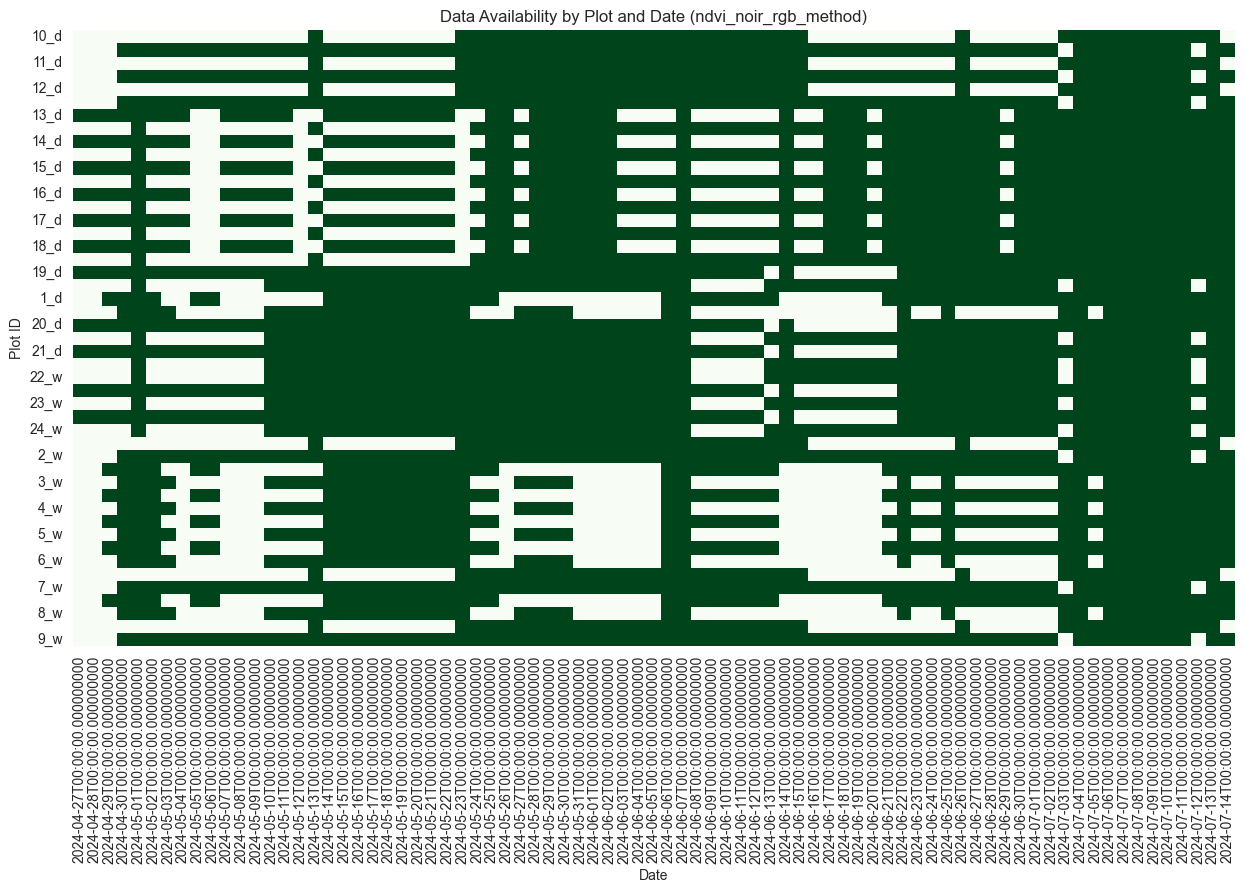

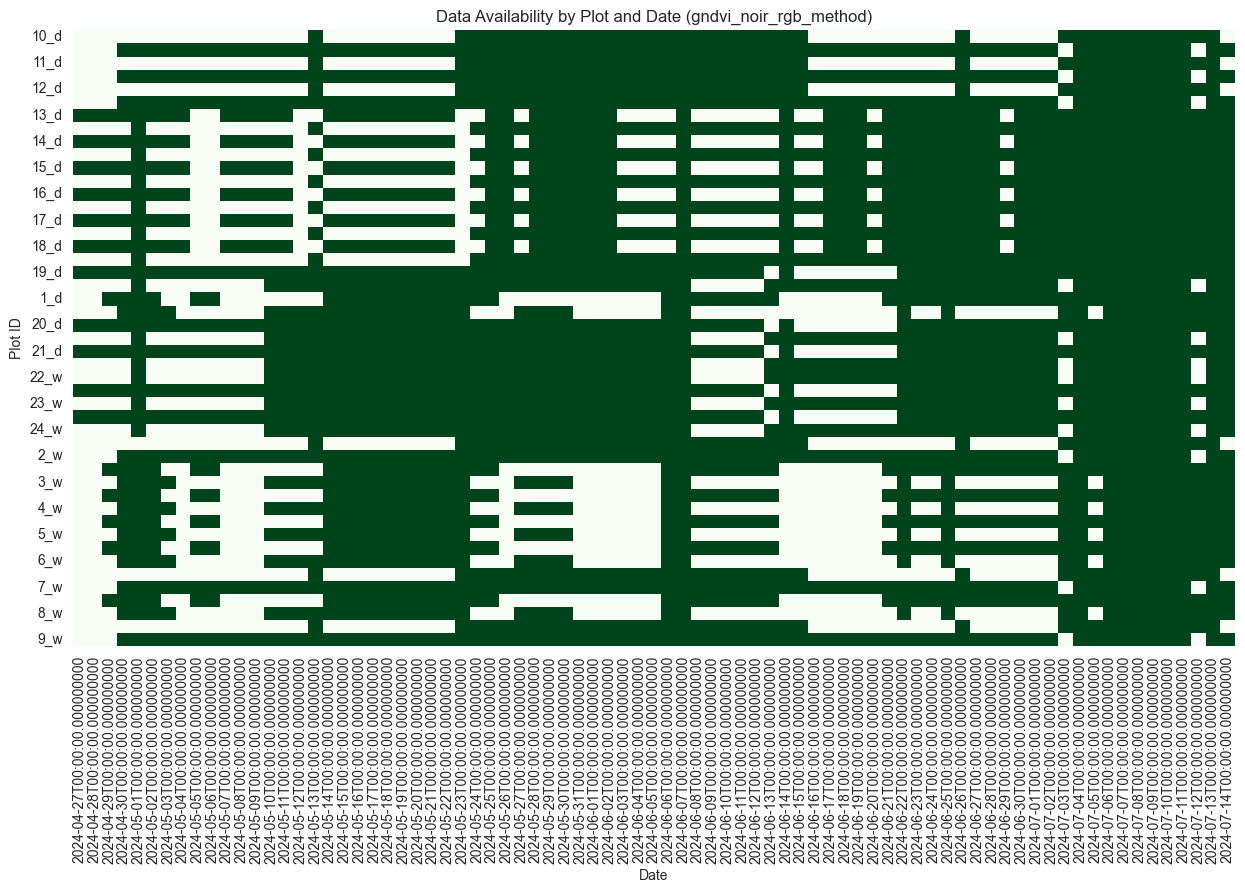

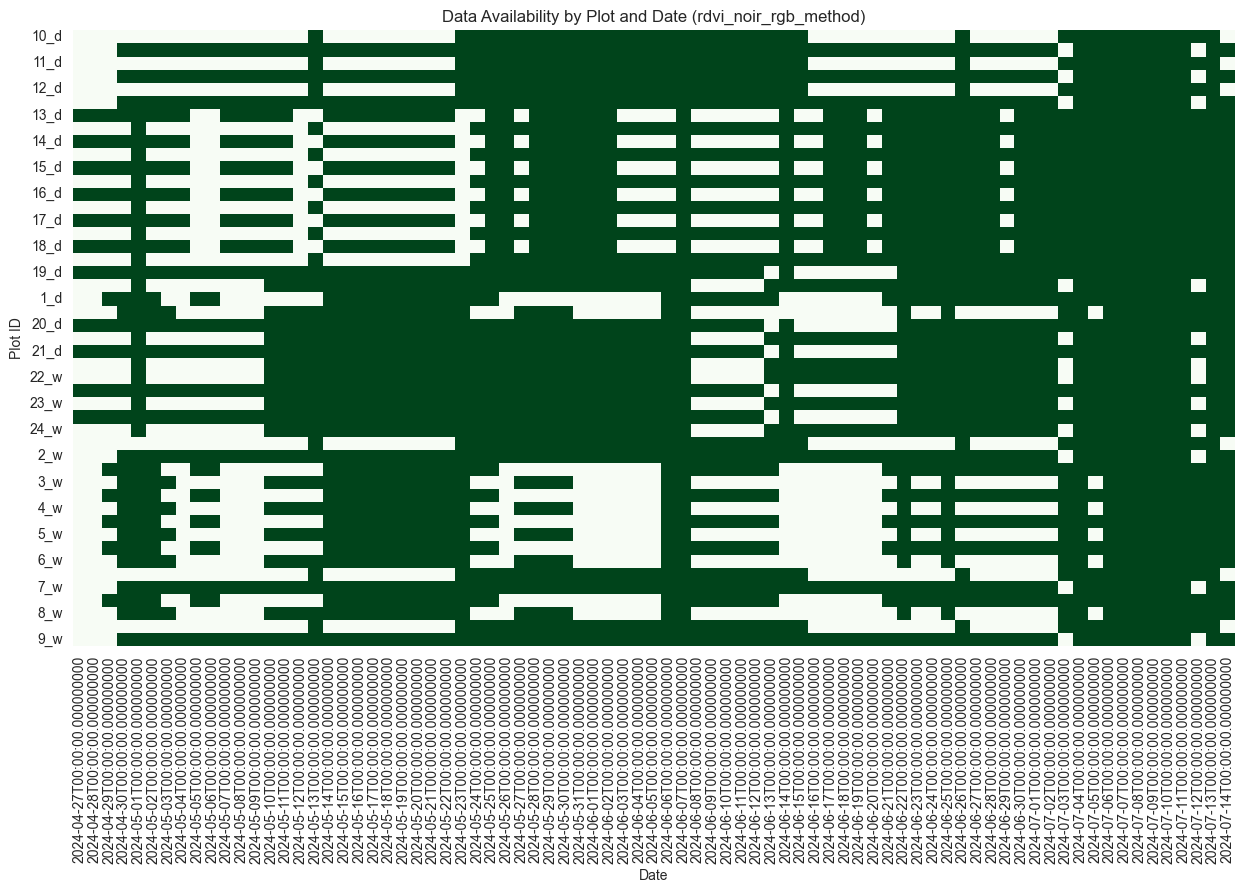

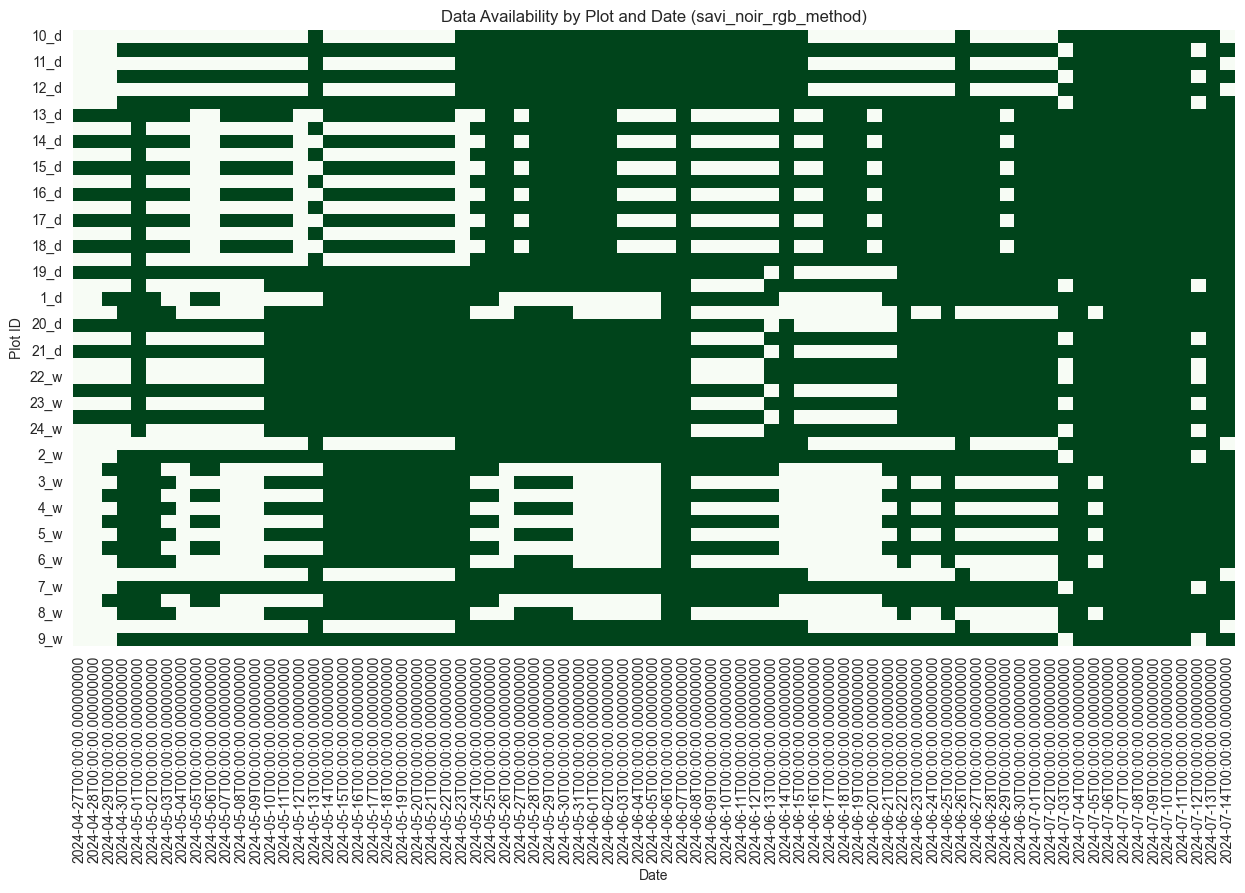

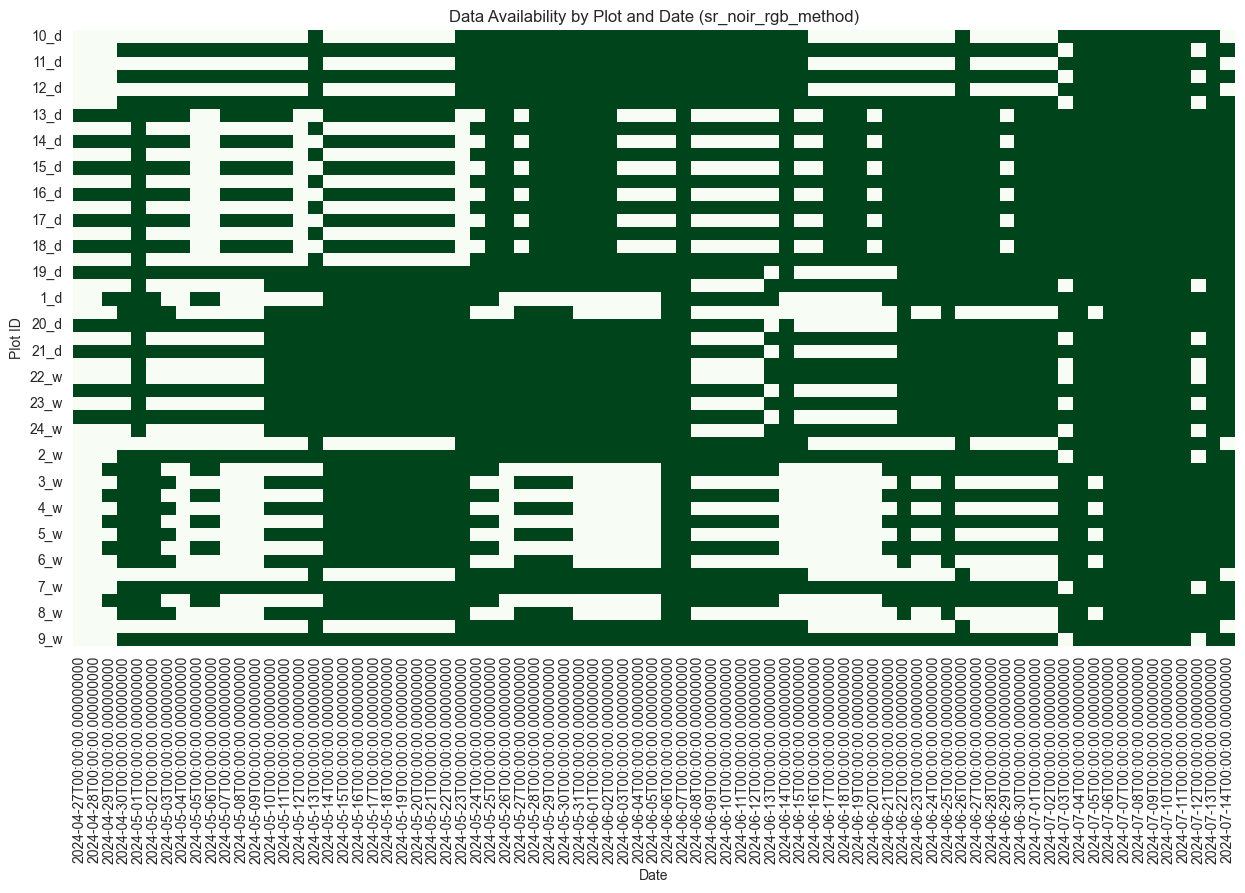

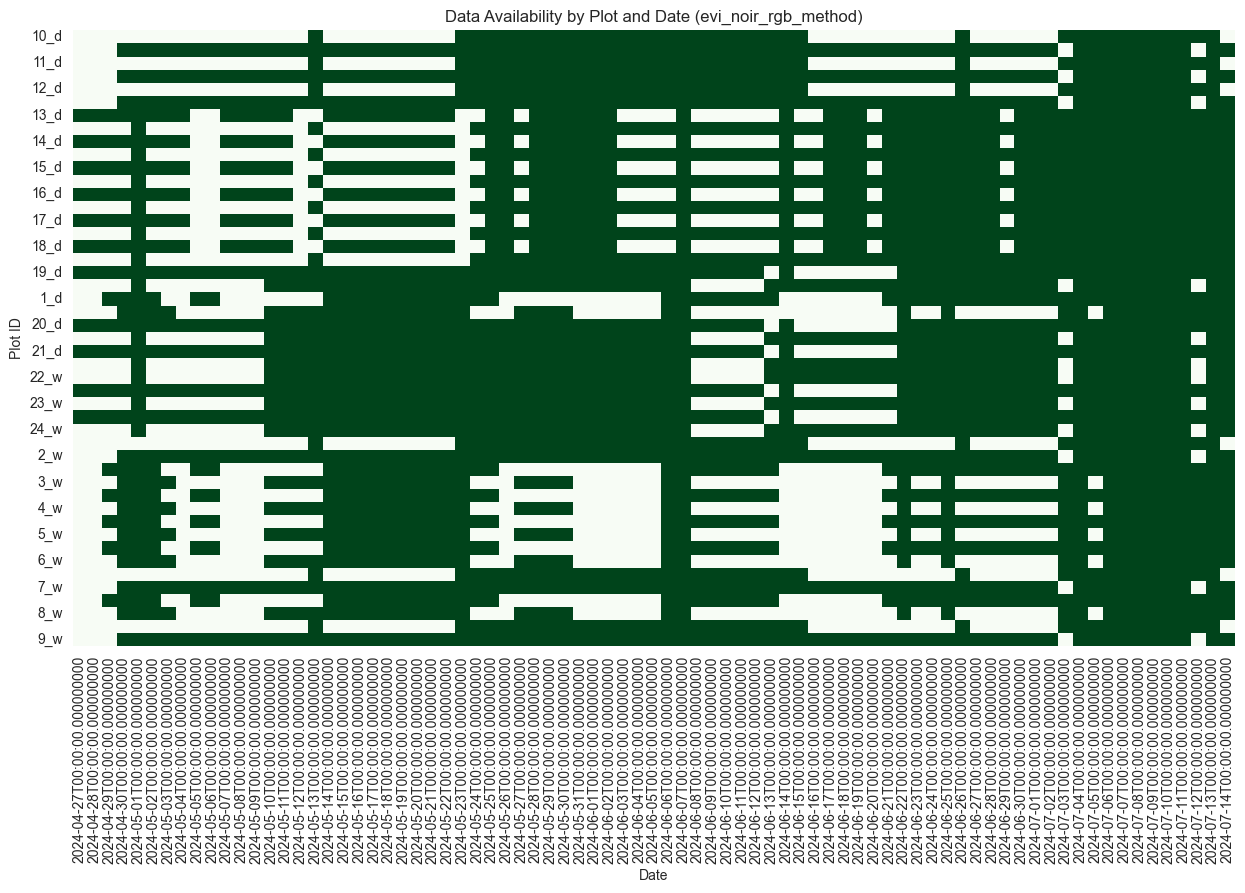

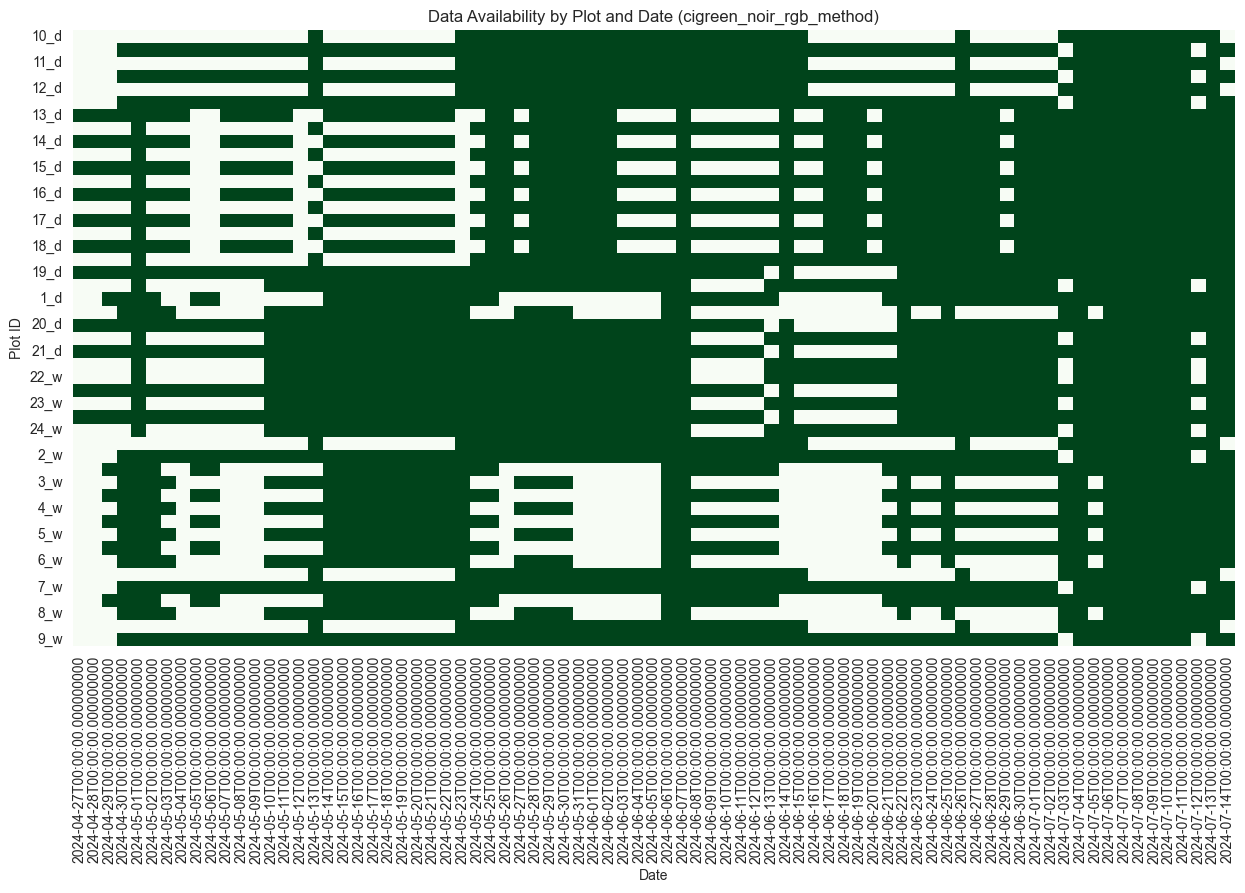

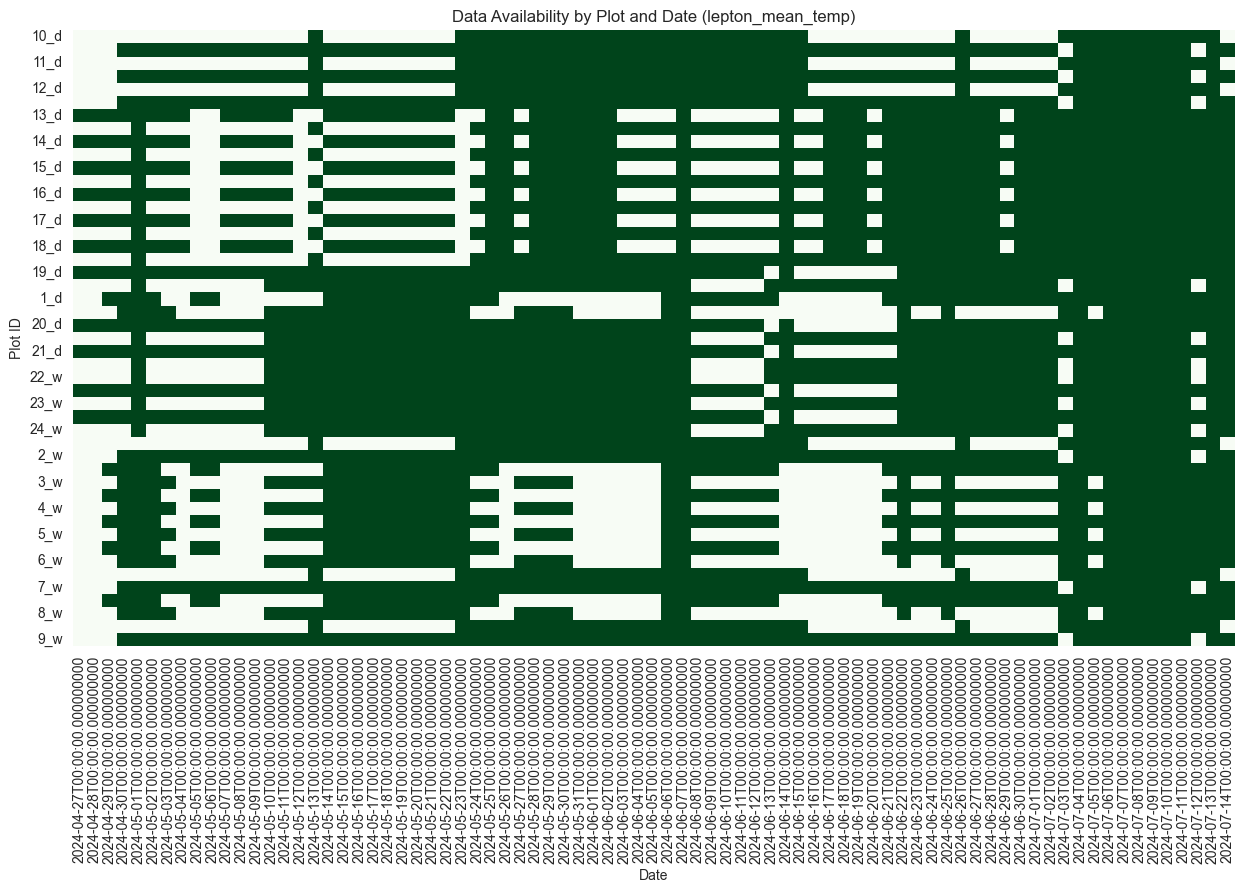

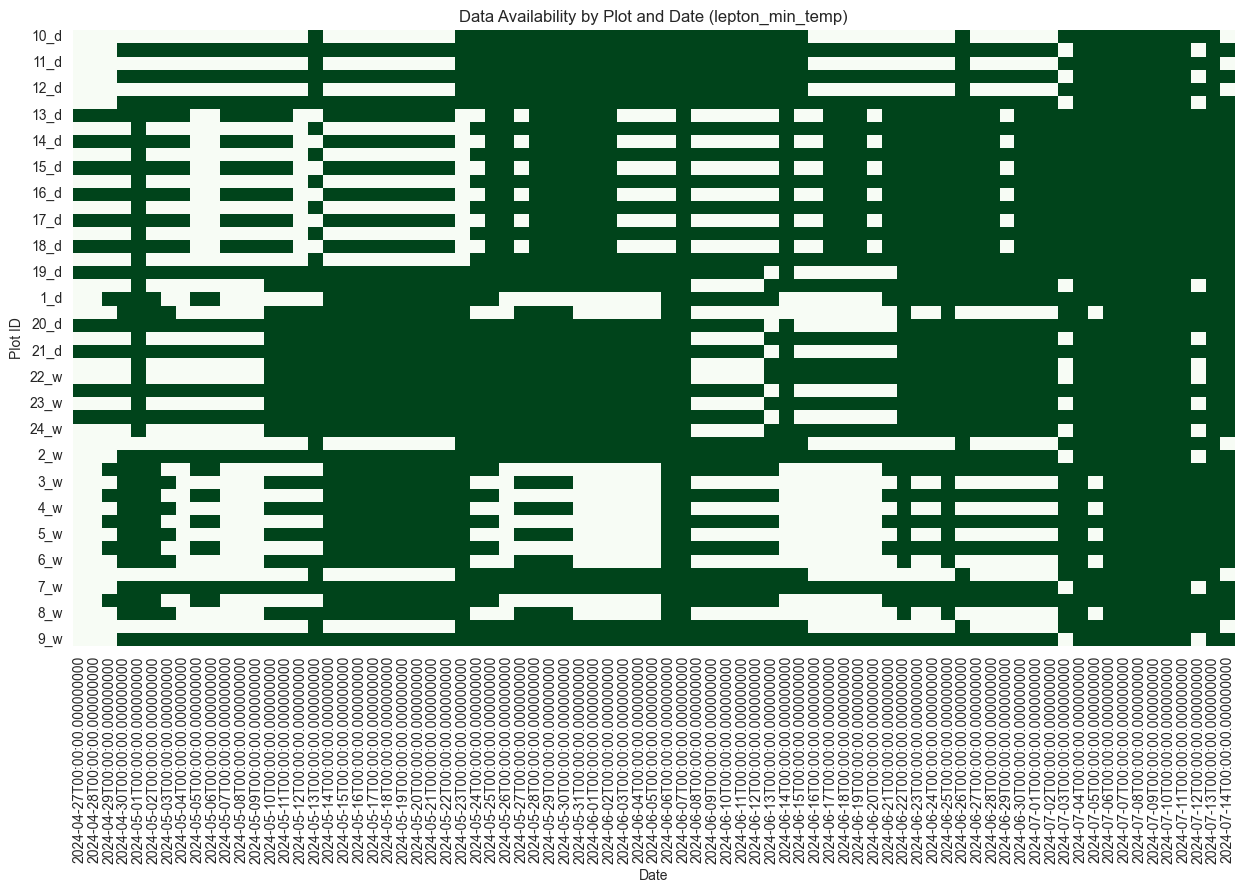

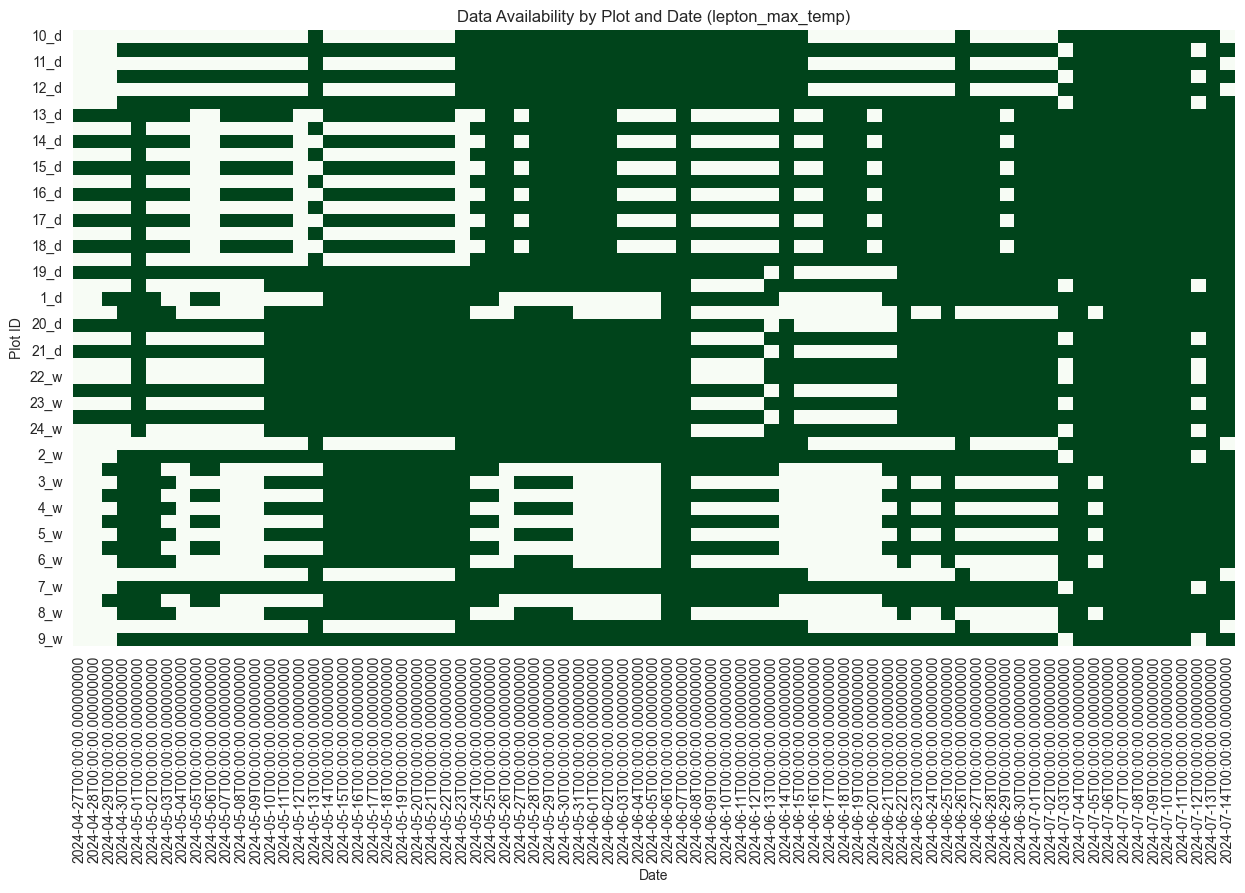

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_available_data(dataset):
    df_avail = dataset.copy()

    for _feature in features:
        presence = df_avail.pivot_table(
            index='plot_id',
            columns='date',
            values=_feature,
            aggfunc='size',
            fill_value=0
        )
        presence = presence.map(lambda x: 1 if x > 0 else 0)

        plt.figure(figsize=(15, 8))
        sns.heatmap(presence, cmap="Greens", cbar=False)
        plt.title(f"Data Availability by Plot and Date ({_feature})")
        plt.xlabel("Date")
        plt.ylabel("Plot ID")
        plt.show()

plot_available_data(df_hour13)

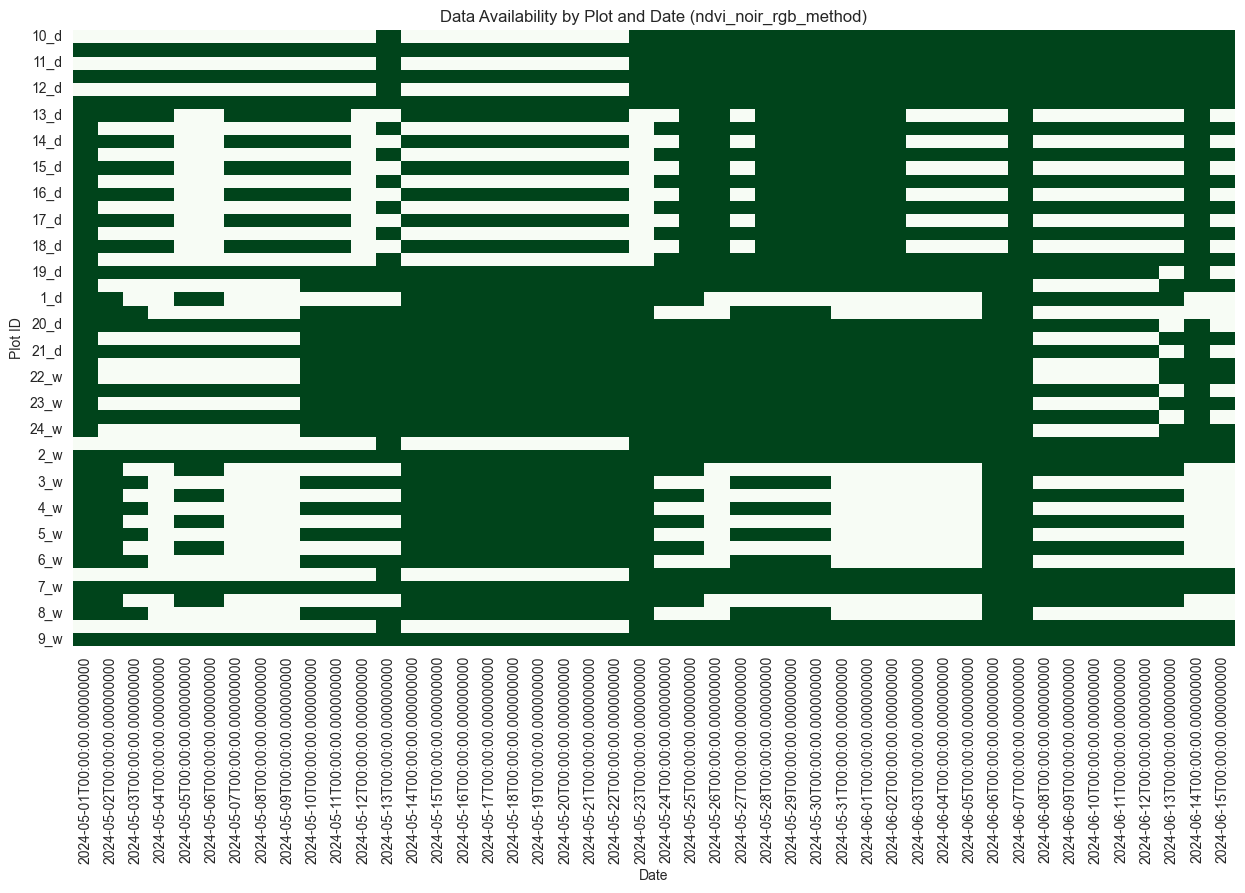

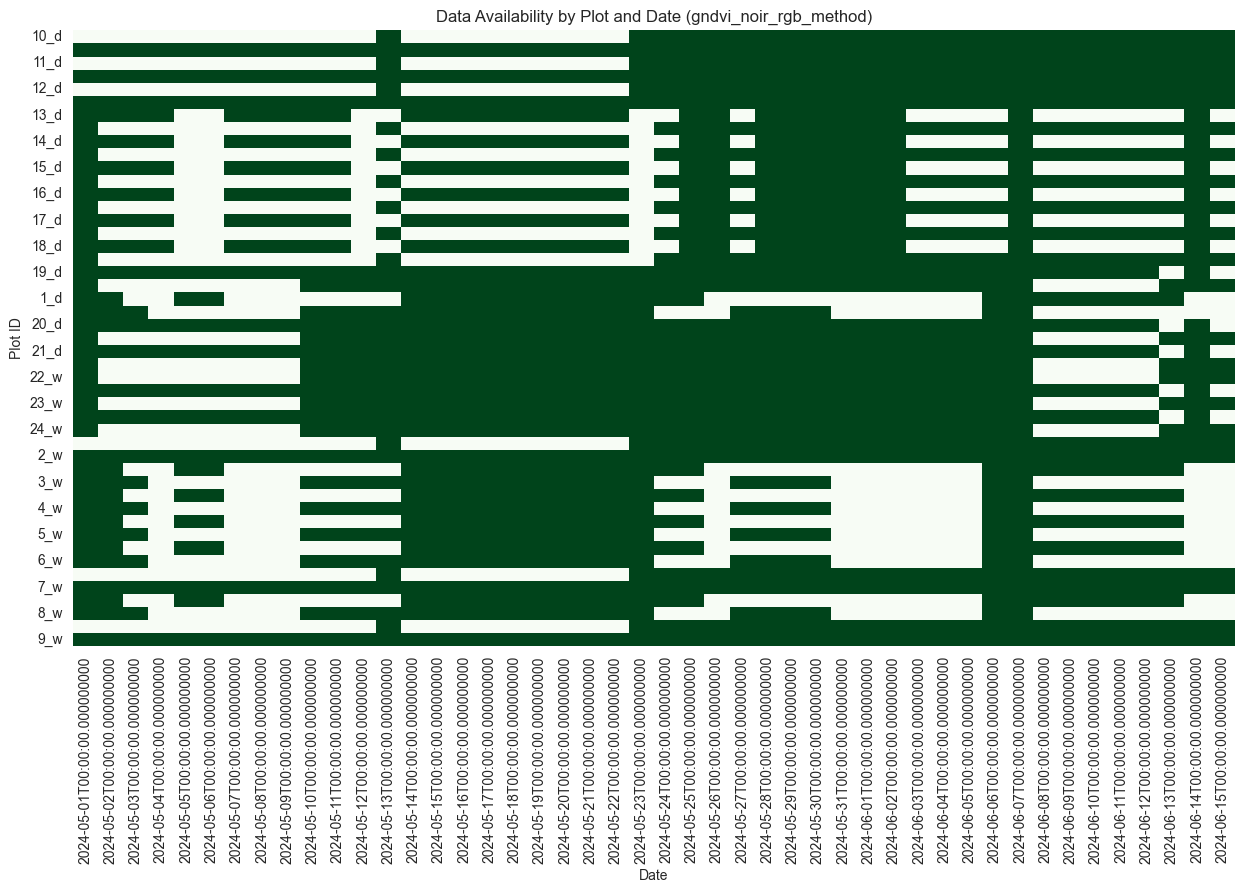

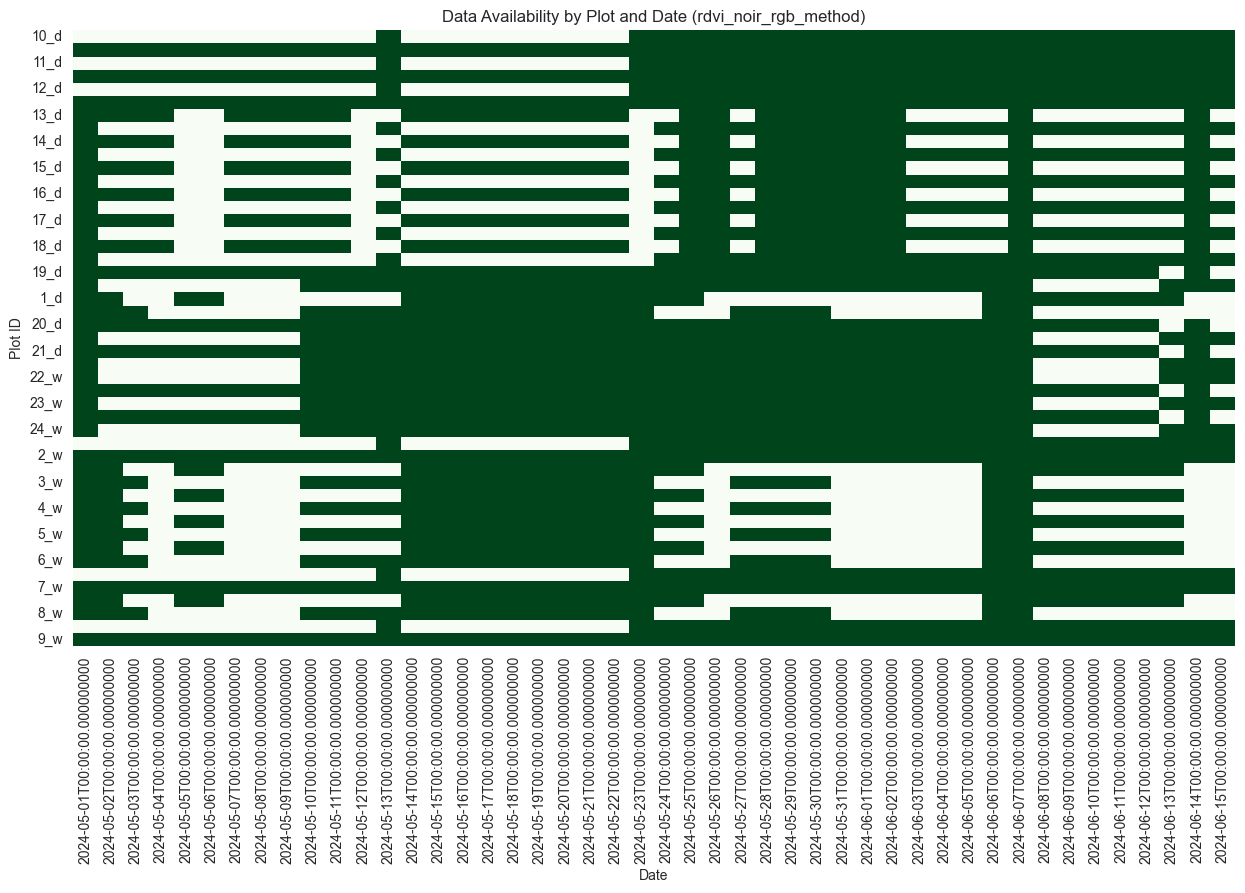

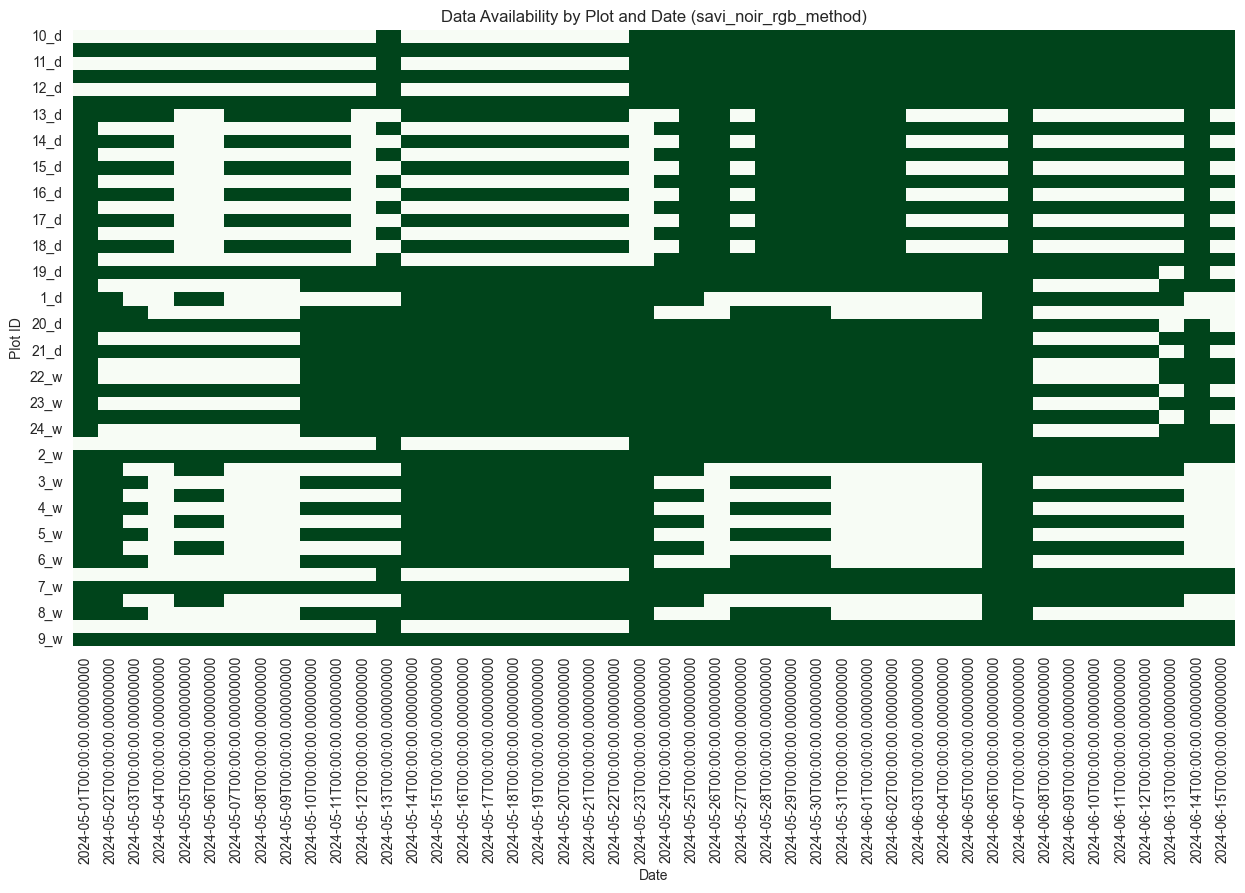

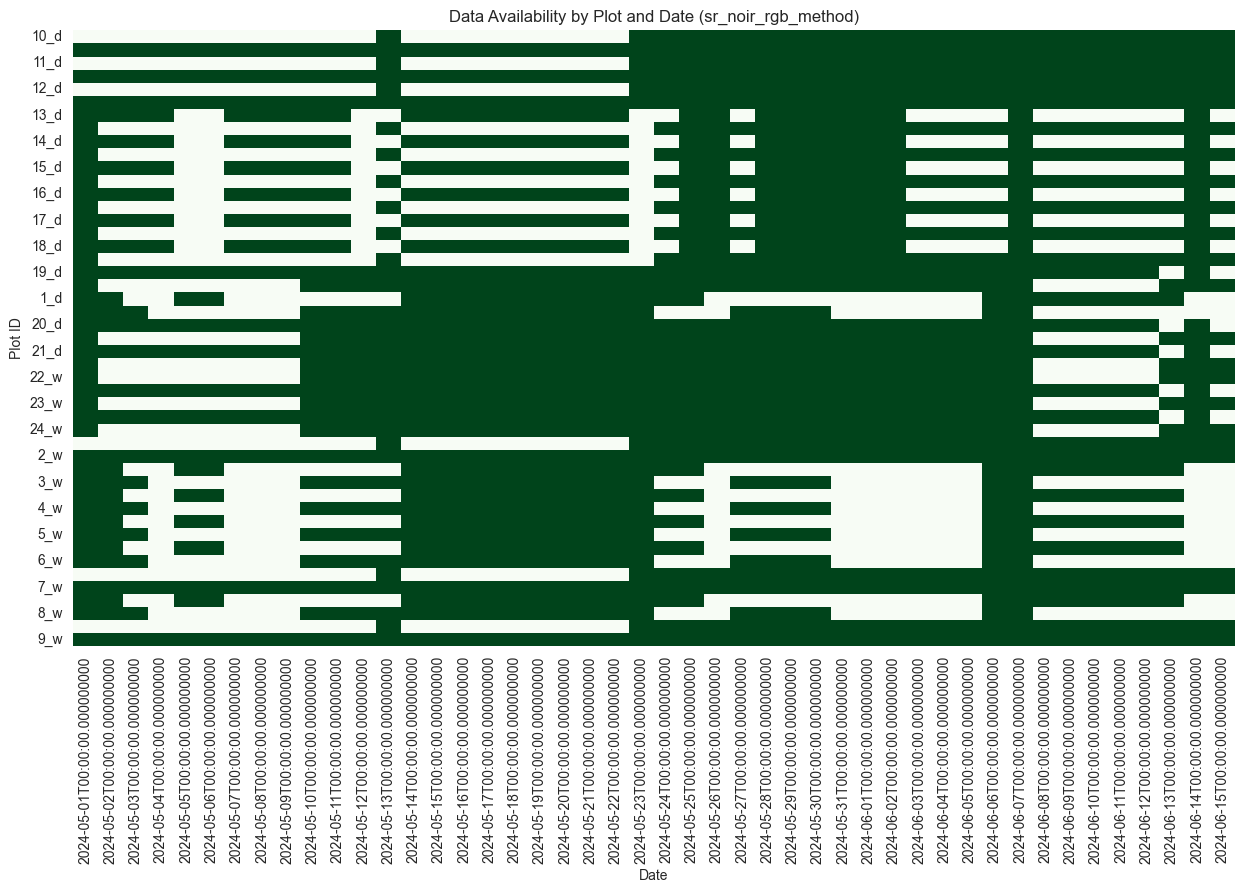

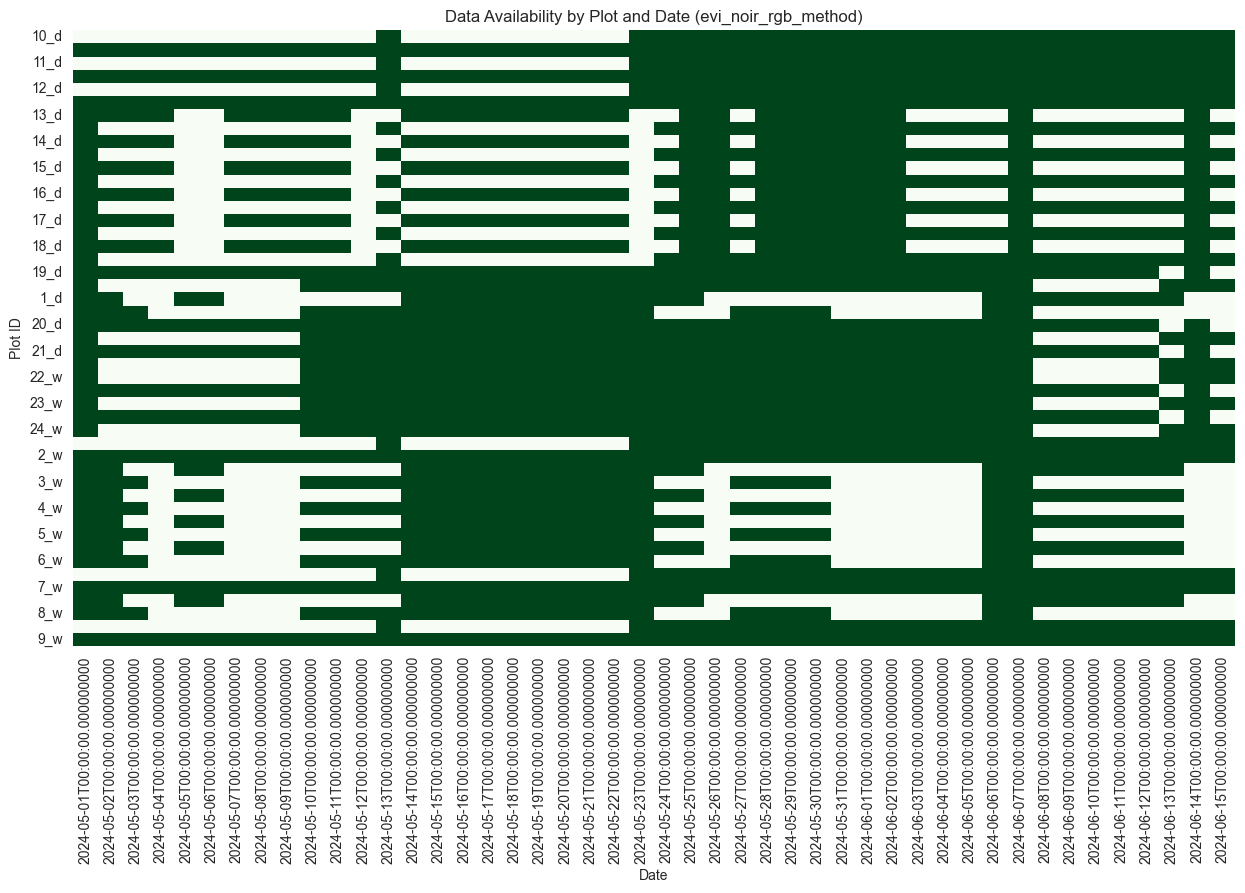

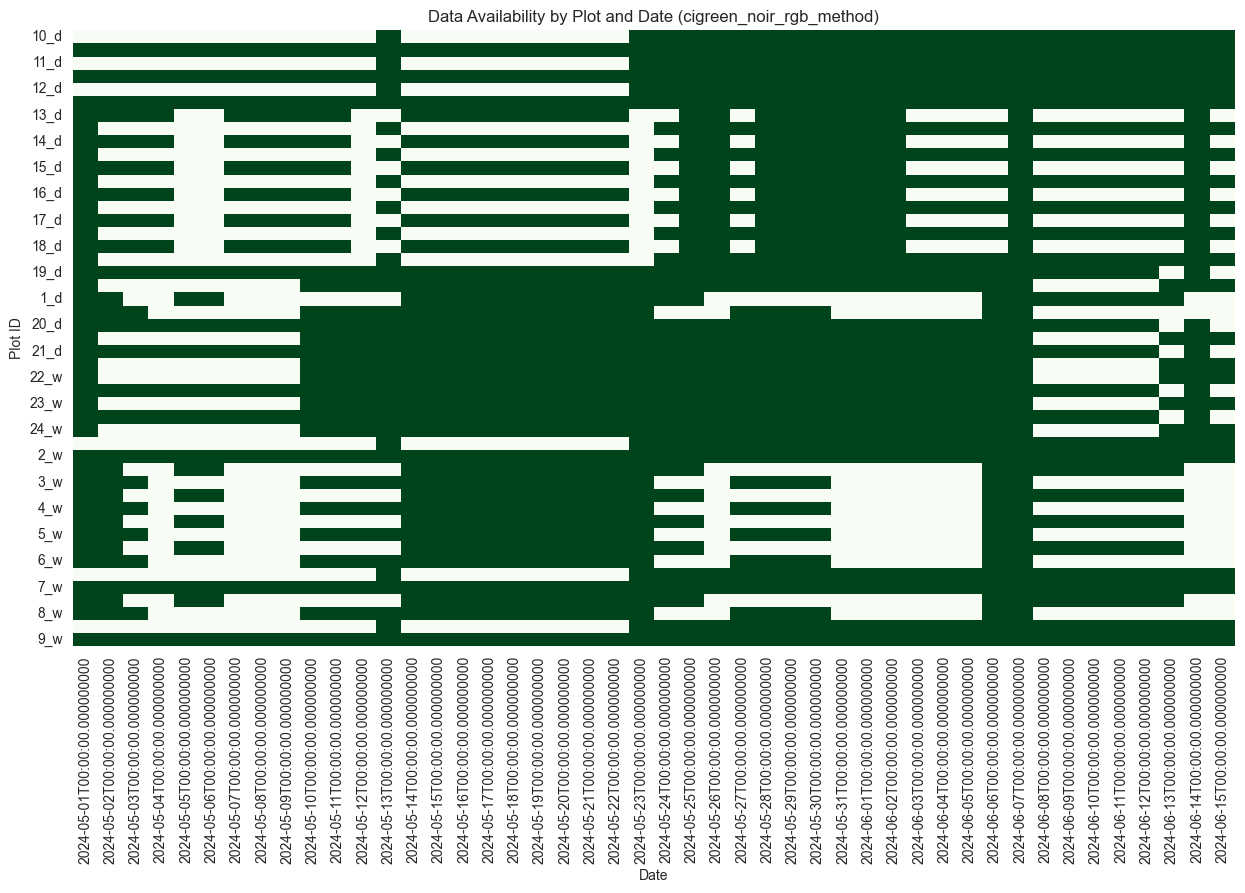

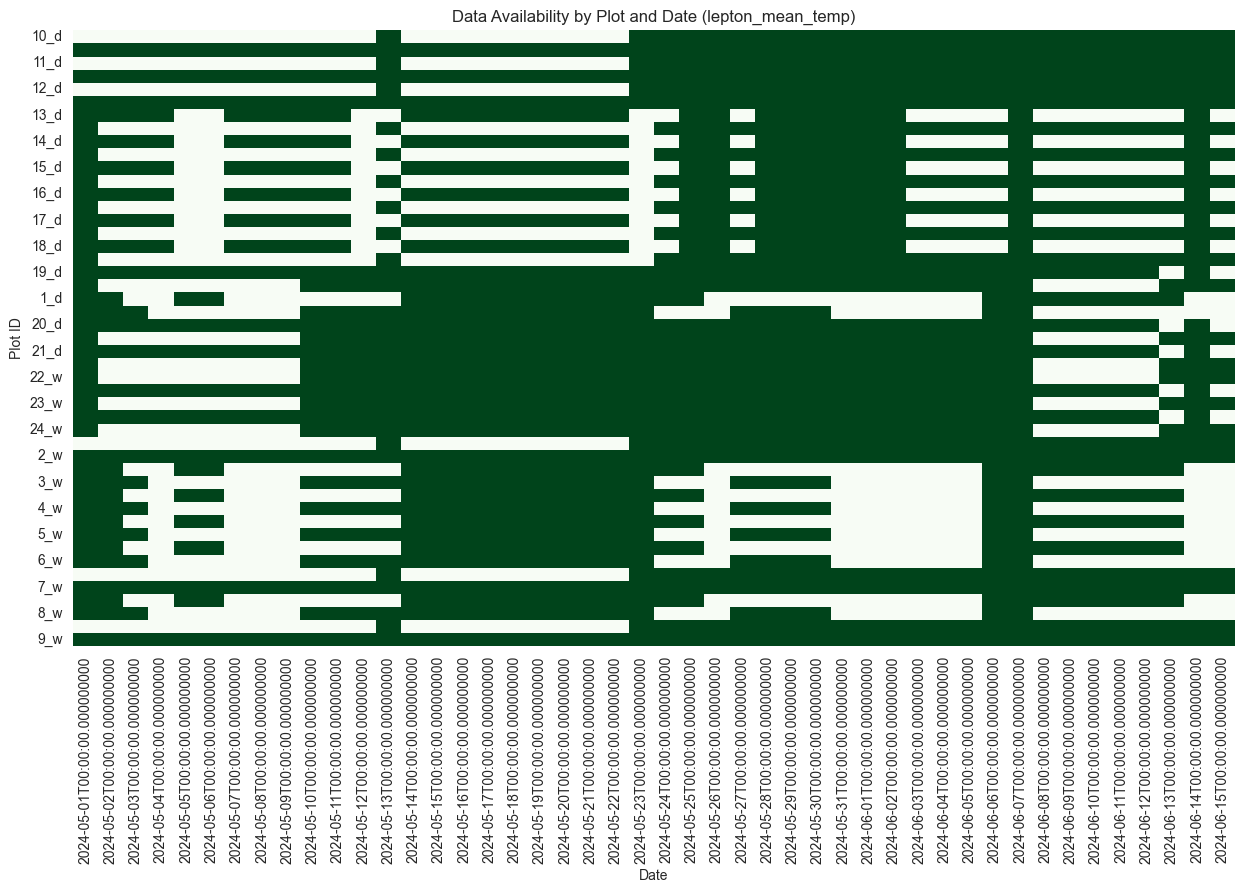

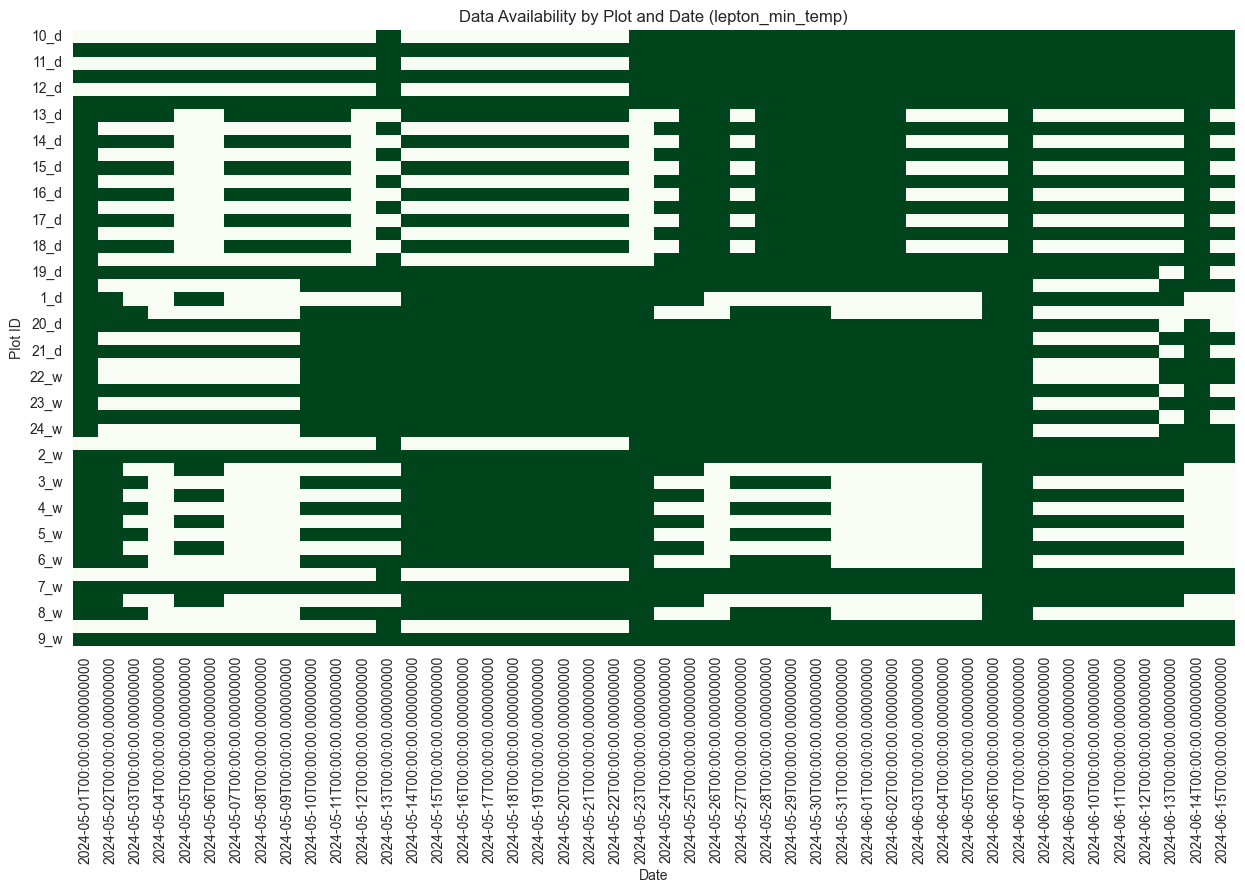

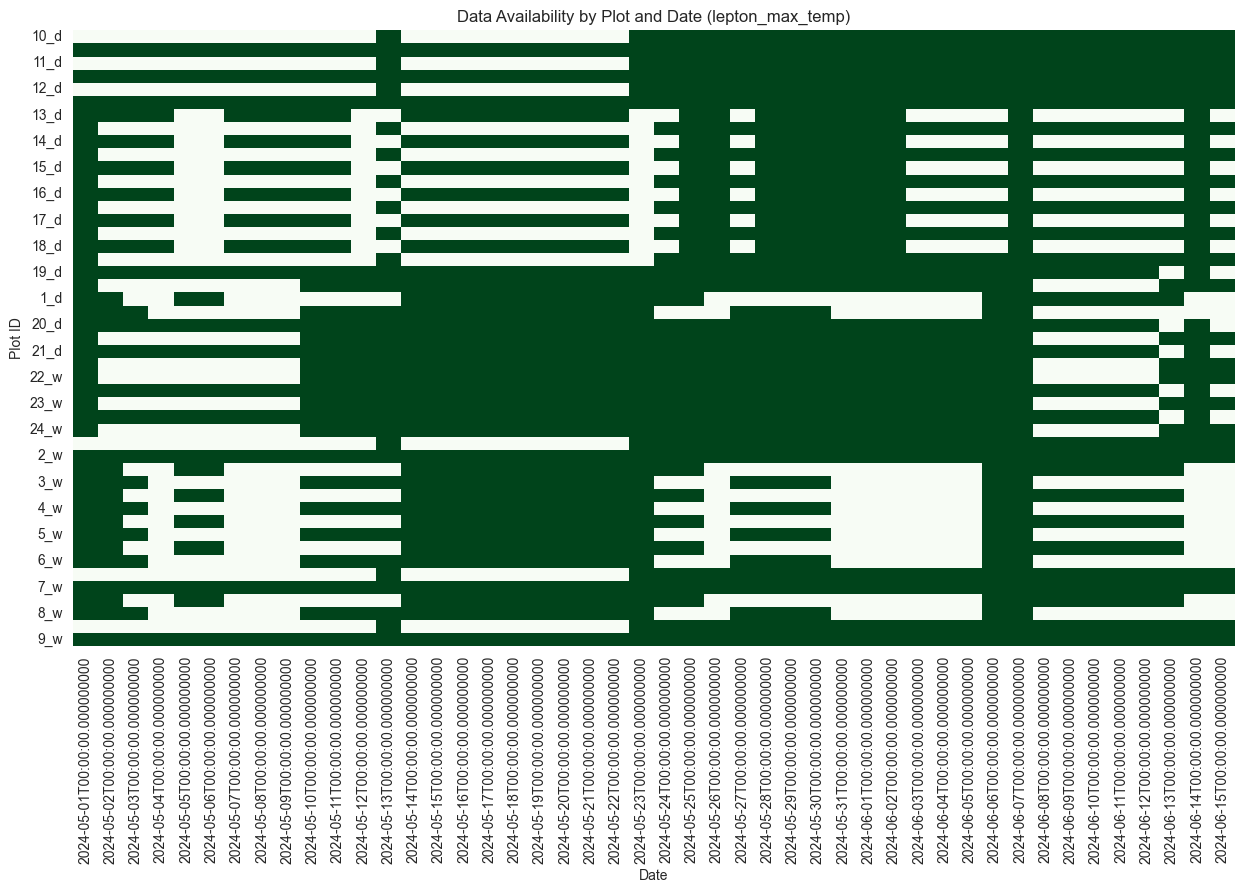

In [78]:
df_hour13 = df_hour13[(df_hour13['date'] >= '2024-05-01') & (df_hour13['date'] <= '2024-06-15')]
plot_available_data(df_hour13)

In [79]:
# Count how many rows per plot_id and date
duplicates = df_hour13.groupby(['plot_id', 'date']).size().reset_index(name='count')

# Filter only those with more than 1 NDVI value
duplicates = duplicates[duplicates['count'] > 1]

print(duplicates) # 0 results, Good!

Empty DataFrame
Columns: [plot_id, date, count]
Index: []


In [80]:
blank_count = df_hour13['lepton_mean_temp'].isna().sum()
print(blank_count)

print(df_hour13.shape)

720
(1444, 13)


Outliers

In [ ]:
# Checking outliers
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_hour13[feature])
    plt.title(feature.upper() + " Boxplot - Outliers Visible")
    plt.show()

In [ ]:
# Removing outliers for each plot
def remove_outliers_iqr_all_features(group):
    for _feature in features:
        Q1 = group[_feature].quantile(0.25)
        Q3 = group[_feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1 * IQR
        upper_bound = Q3 + 1 * IQR
        group = group[(group[_feature] >= lower_bound) & (group[_feature] <= upper_bound)]
    return group

# Clean per plot_id
df_clean = df_hour13.groupby('plot_id', group_keys=False).apply(remove_outliers_iqr_all_features)

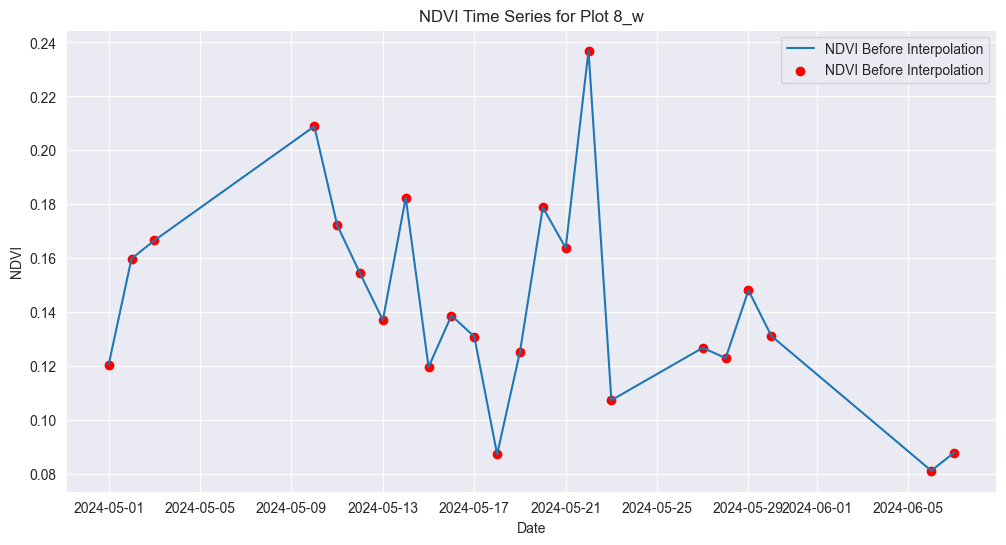

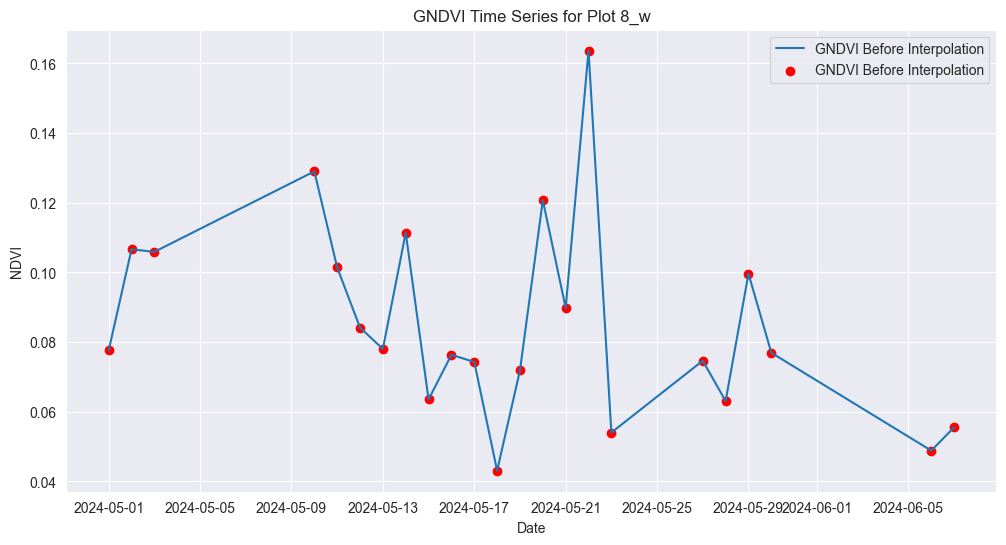

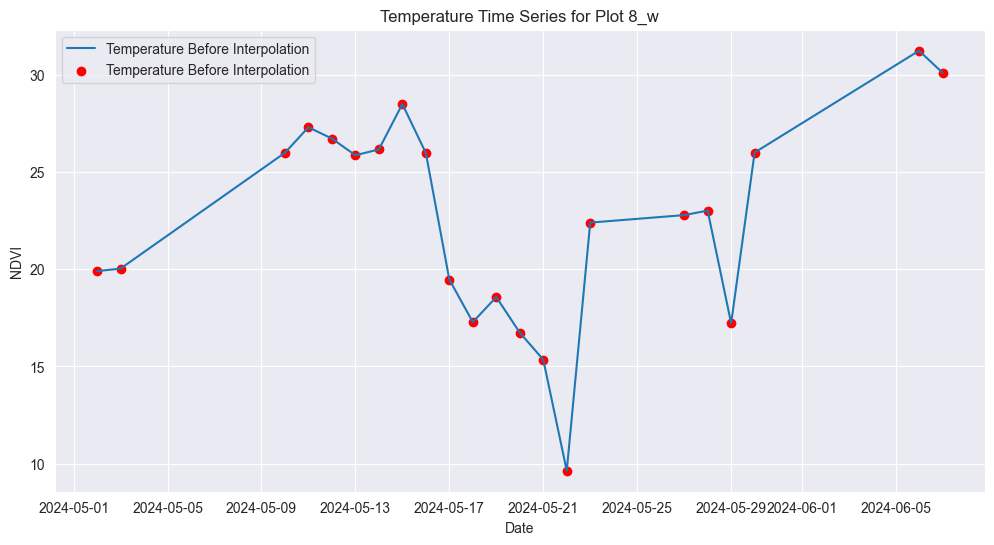

In [81]:
# Plot the NDVI over the time
plot_to_check = "8_w"

def plot_VI_over_time_per_plot(plot_no, feature_name, vi_name, non_interpolated_dataset, with_interpolation=False, interpolation_method="", interpolated_dataset=None):

    plot_data = non_interpolated_dataset[non_interpolated_dataset['plot_id'] == plot_no]

    plt.figure(figsize=(12,6))

    if with_interpolation:
        if interpolated_dataset is None:
            raise ValueError("Interpolated dataset is missing in the arguments")
        plot_data_interpolated = interpolated_dataset[interpolated_dataset['plot_id'] == plot_no]
        plt.plot(plot_data_interpolated['date'], plot_data_interpolated[feature_name], label=interpolation_method + ' Interpolated ' + vi_name)
        plt.scatter(plot_data_interpolated['date'], plot_data_interpolated[feature_name], label=interpolation_method + ' Interpolated ' + vi_name)
    else:
        plt.plot(plot_data['date'], plot_data[feature_name], label=vi_name + ' Before Interpolation')

    plt.scatter(plot_data['date'], plot_data[feature_name], color='red', label=vi_name + ' Before Interpolation')
    plt.title(f"{vi_name} Time Series for Plot {plot_no}")
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.show()

plot_VI_over_time_per_plot(plot_to_check, 'ndvi_noir_rgb_method' , "NDVI", df_hour13)
plot_VI_over_time_per_plot(plot_to_check, 'gndvi_noir_rgb_method' , "GNDVI",df_hour13)
plot_VI_over_time_per_plot(plot_to_check, 'lepton_mean_temp' , "Temperature",df_hour13)

In [82]:
all_dates = pd.date_range(df_hour13['date'].min(), df_hour13['date'].max(), freq="D")

num_na_rows = df_hour13.isna().any(axis=1).sum()
print(f"df_hour13 Rows with at least one NaN: {num_na_rows}")

blank_count = df_hour13['lepton_mean_temp'].isna().sum()
print(blank_count)

print(df_hour13.shape)


df_hour13 Rows with at least one NaN: 720
720
(1444, 13)


In [83]:
from scipy.interpolate import PchipInterpolator

def interpolate_plot(plot, method, doSmoothing= False):
    plot = plot.set_index('date').sort_index()
    plot = plot.reindex(all_dates)
    plot['plot_id'] = plot['plot_id'].ffill().bfill()

    if method == "pchip":
        for _feature in vi_features:
            vi = plot[_feature]
            if vi.notna().sum() >= 2:
                valid = vi.dropna()
                interpolator = PchipInterpolator(valid.index, valid.values)
                plot[_feature] = interpolator(plot.index)
            else:
                # Not enough data → forward/backward fill
                plot[_feature] = vi.ffill().bfill()
    elif method == "polynomial" or method == "spline":
        if doSmoothing:
            plot[vi_features] = (plot[vi_features].interpolate(method=method, order=2, limit_direction='both')
                                        .rolling(window=3, min_periods=1, center=True).mean())
        else:
            plot[vi_features] = plot[vi_features].interpolate(method=method, order=2, limit_direction='both')
    else:
        if doSmoothing:
            plot[vi_features] = (plot[vi_features].interpolate(method=method,limit_direction='both')
                                        .rolling(window=3, min_periods=1, center=True).mean())
        else:
            plot[vi_features] = plot[vi_features].interpolate(method=method,limit_direction='both')

    plot[output_variable] = plot[output_variable].ffill().bfill()  # same yield for whole plot
    plot = plot.reset_index().rename(columns={'index': 'date'})
    return plot


In [84]:

# Apply linear interpolation
# Without smoothing
df_linear_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='linear')
    .reset_index(drop=True)
)
num_na_rows = df_linear_interpolated.isna().any(axis=1).sum()
print(f"df_linear_interpolated Rows with at least one NaN: {num_na_rows}")

blank_count = df_linear_interpolated['ndvi_noir_rgb_method'].isna().sum()
print(f"df_linear_interpolated ndvi_noir_rgb_method NaN: {blank_count}")

blank_count = df_linear_interpolated['lepton_mean_temp'].isna().sum()
print(f"df_linear_interpolated lepton_mean_temp NaN: {blank_count}")

print(df_linear_interpolated.shape)

# With smoothing
df_linear_interpolated_and_smoothed = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='linear', doSmoothing=True)
    .reset_index(drop=True)
)
num_na_rows = df_linear_interpolated_and_smoothed.isna().any(axis=1).sum()
print(f"df_linear_interpolated_and_smoothed Rows with at least one NaN: {num_na_rows}")

df_linear_interpolated Rows with at least one NaN: 1438
df_linear_interpolated ndvi_noir_rgb_method NaN: 0
df_linear_interpolated lepton_mean_temp NaN: 1438
(2162, 13)
df_linear_interpolated_and_smoothed Rows with at least one NaN: 1438


C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\2179254369.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='linear')
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\2179254369.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='linear', doSmoothing=True)


In [85]:
# Apply time interpolation
df_time_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='time')
    .reset_index(drop=True)
)
num_na_rows = df_time_interpolated.isna().any(axis=1).sum()
print(f"df_time_interpolated Rows with at least one NaN: {num_na_rows}")
# Linear and time interpolations looks the same

df_time_interpolated Rows with at least one NaN: 1438


C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\835799018.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='time')


C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\2389814916.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='polynomial')


df_polynomial_interpolated Rows with at least one NaN: 1438


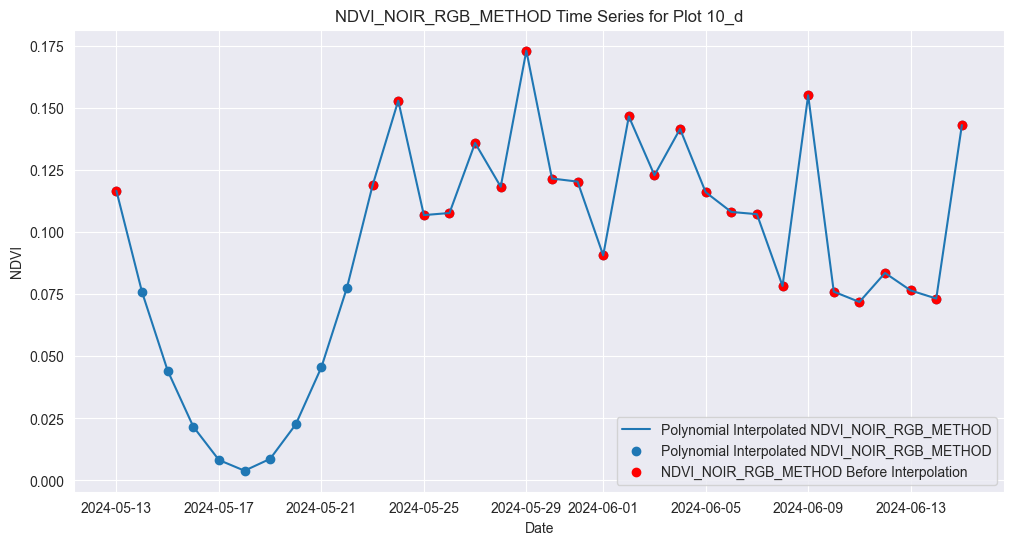

In [86]:
# Apply polynomial interpolation
df_polynomial_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='polynomial')
    .reset_index(drop=True)
)
plot_to_check = "10_d"
num_na_rows = df_polynomial_interpolated.isna().any(axis=1).sum()
print(f"df_polynomial_interpolated Rows with at least one NaN: {num_na_rows}")

plot_VI_over_time_per_plot(plot_to_check, feature_name=features[0], vi_name=features[0].upper(), non_interpolated_dataset=df_hour13, with_interpolation=True, interpolation_method="Polynomial",
                           interpolated_dataset=df_polynomial_interpolated)
# Polynomial curve overshoot between points. Does not interpolate well for NDVI.

In [87]:
# Apply spline interpolation
#without smoothing
df_spline_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='spline')
    .reset_index(drop=True)
)
num_na_rows = df_spline_interpolated.isna().any(axis=1).sum()
print(f"df_spline_interpolated Rows with at least one NaN: {num_na_rows}")
# with smoothing
df_spline_interpolated_and_smoothed = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='spline', doSmoothing=True)
    .reset_index(drop=True)
)
num_na_rows = df_spline_interpolated_and_smoothed.isna().any(axis=1).sum()
print(f"df_spline_interpolated_and_smoothed Rows with at least one NaN: {num_na_rows}")

df_spline_interpolated Rows with at least one NaN: 1438
df_spline_interpolated_and_smoothed Rows with at least one NaN: 1438


C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\2343209632.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='spline')
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\2343209632.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='spline', doSmoothing=True)


In [88]:
#Piecewise Cubic Hermite (PCHIP) Interpolation
df_PCHIP_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='pchip')
    .reset_index(drop=True)
)


C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\4284854885.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_plot, method='pchip')


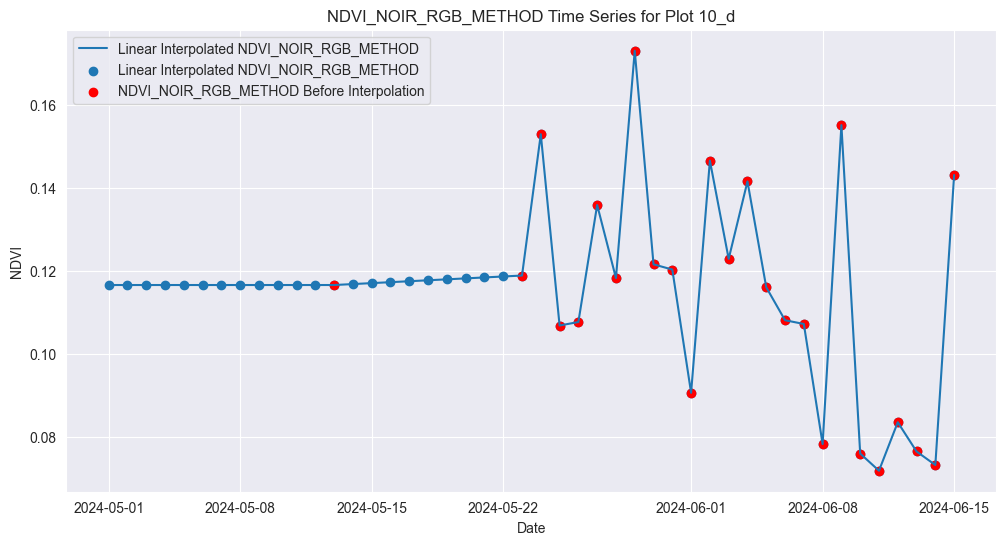

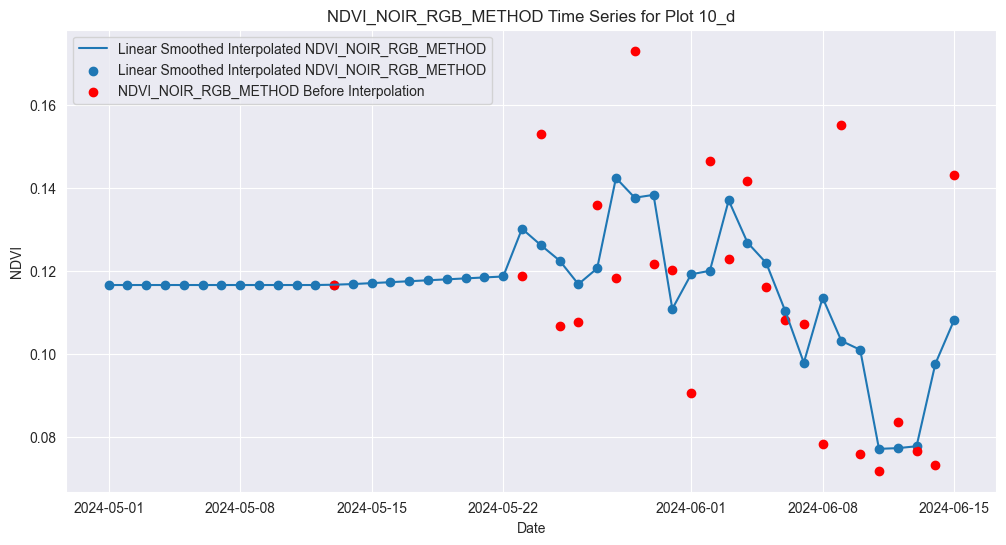

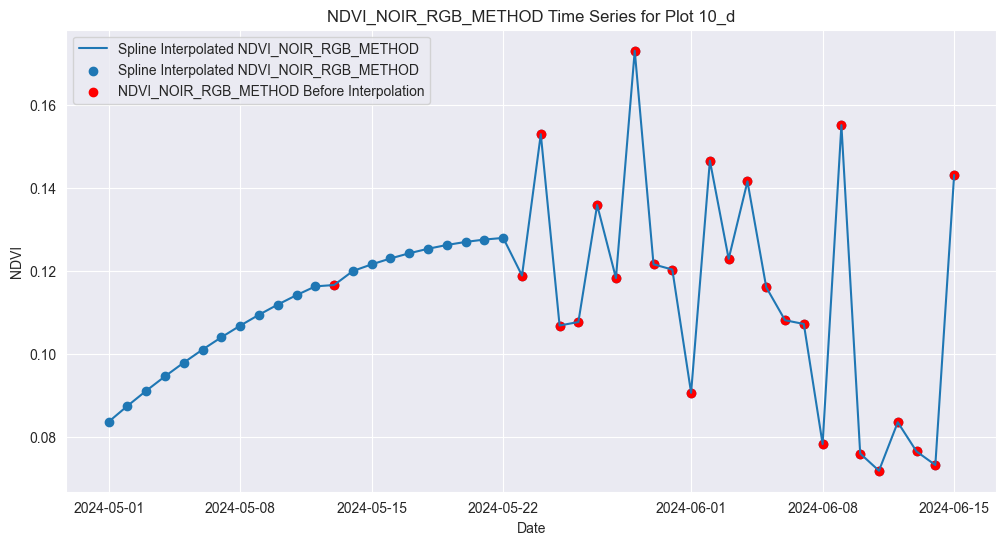

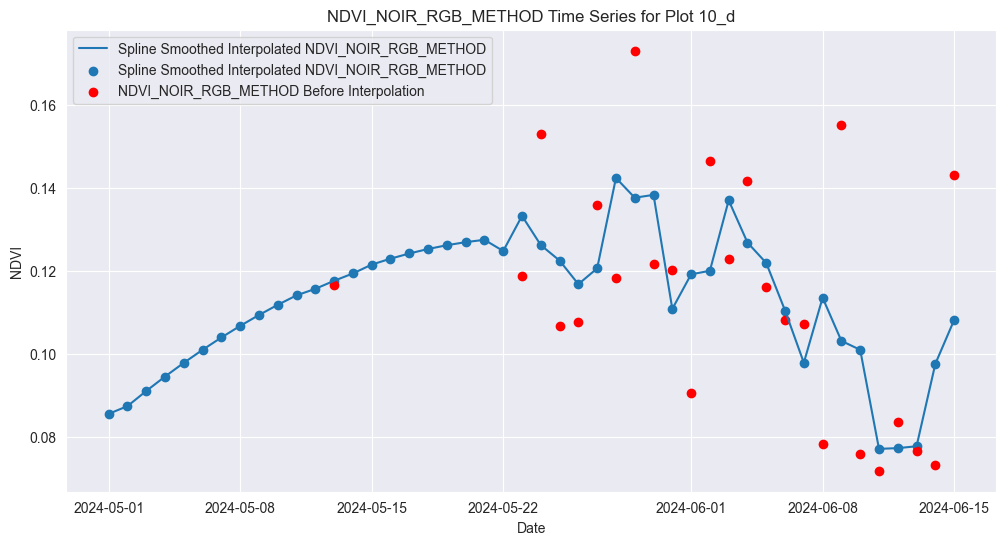

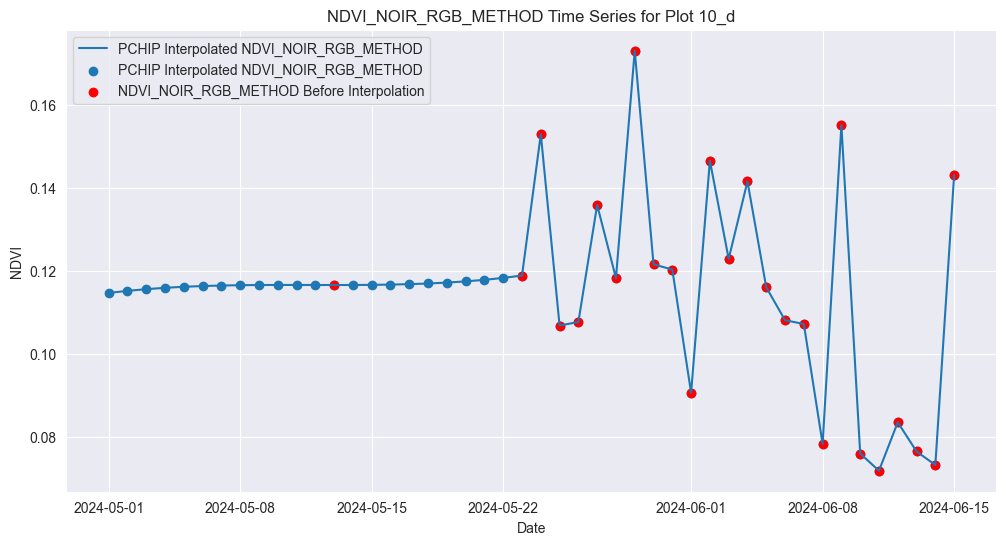

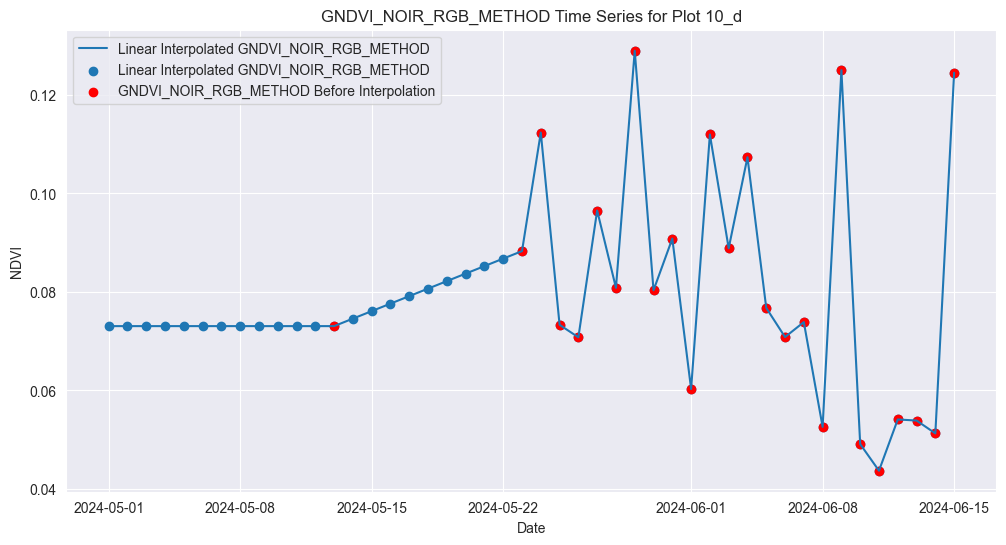

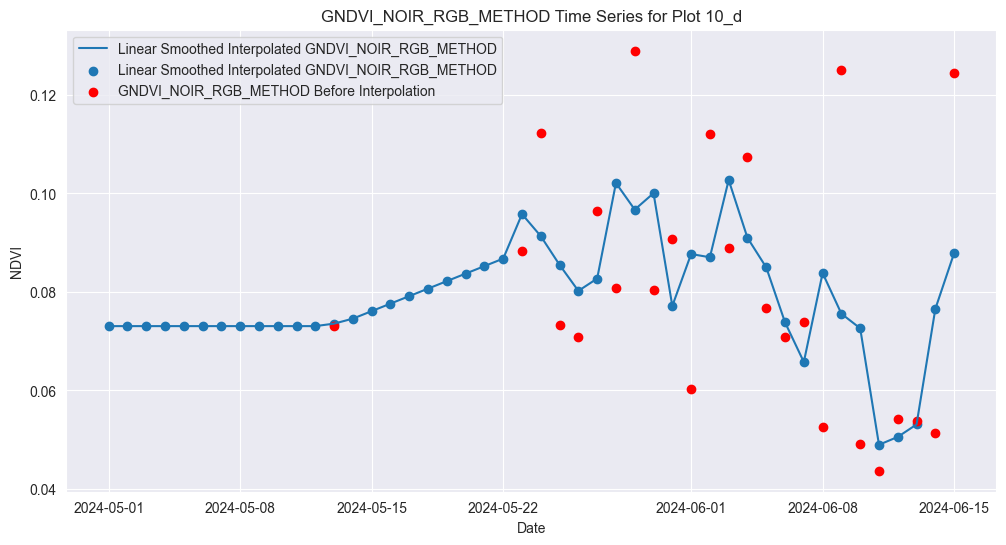

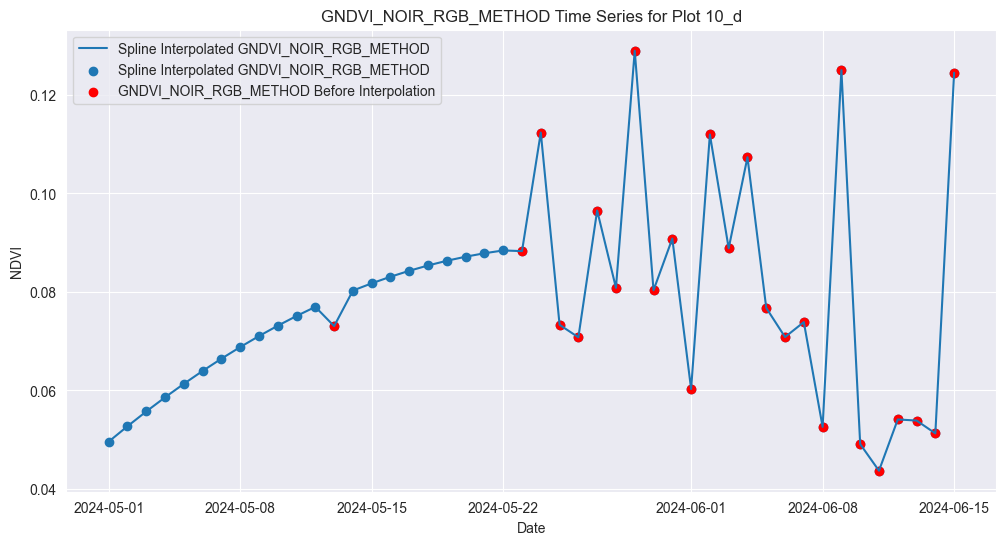

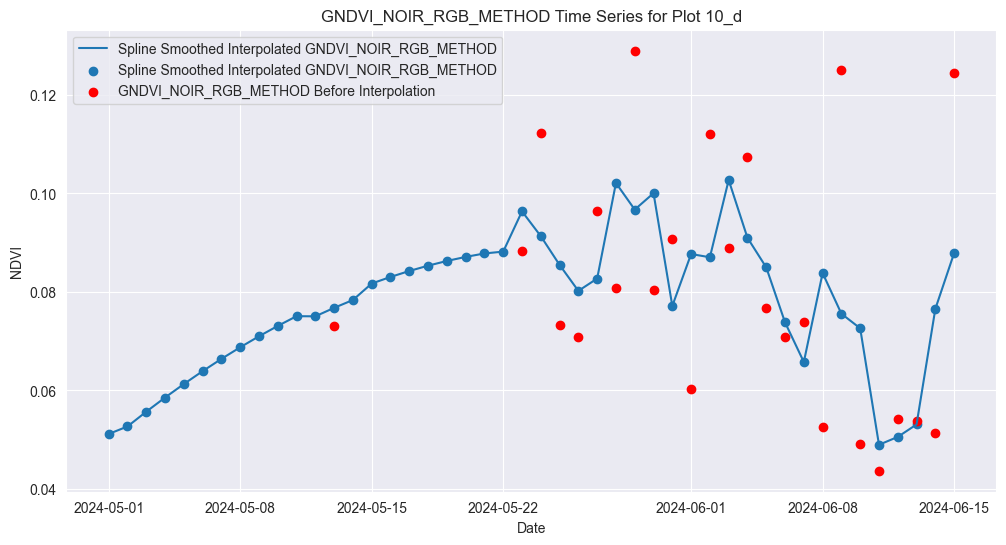

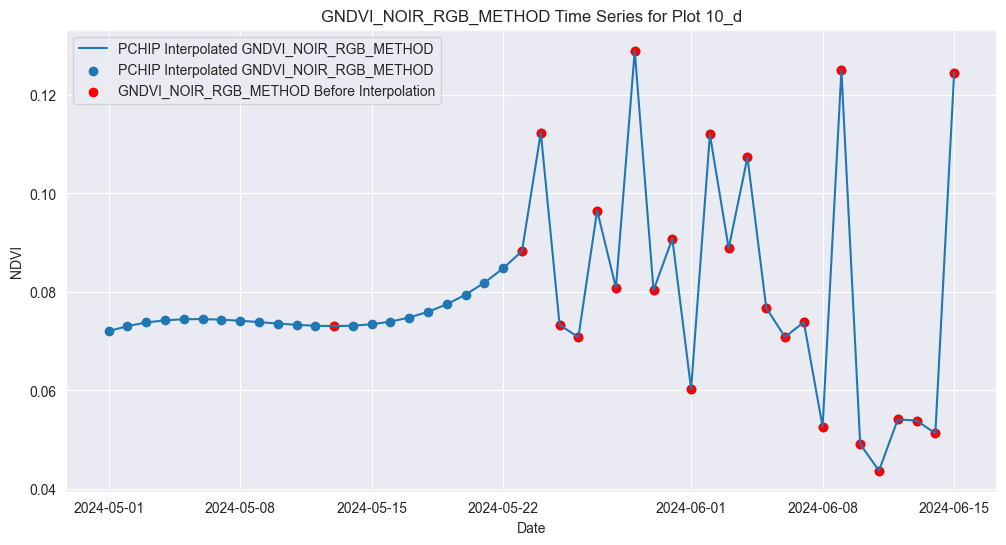

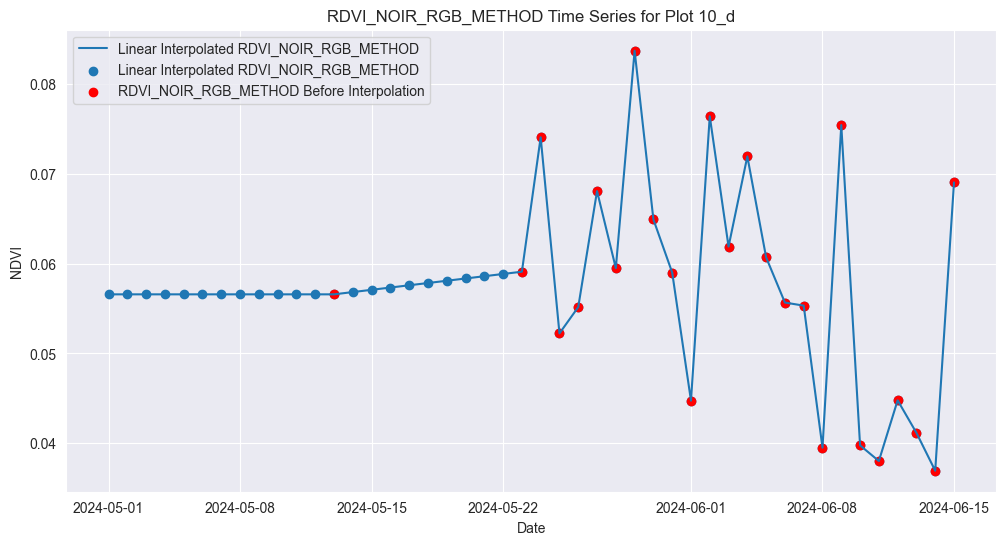

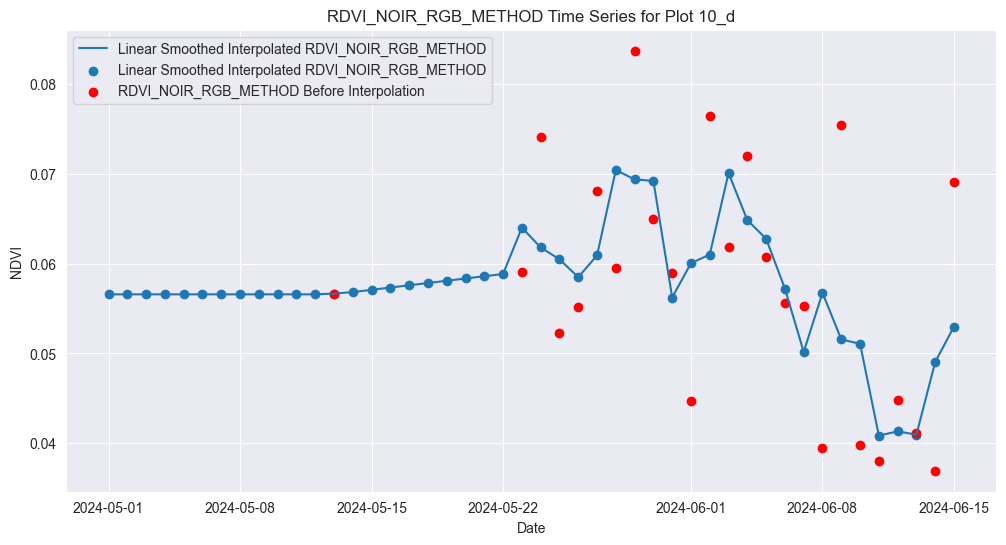

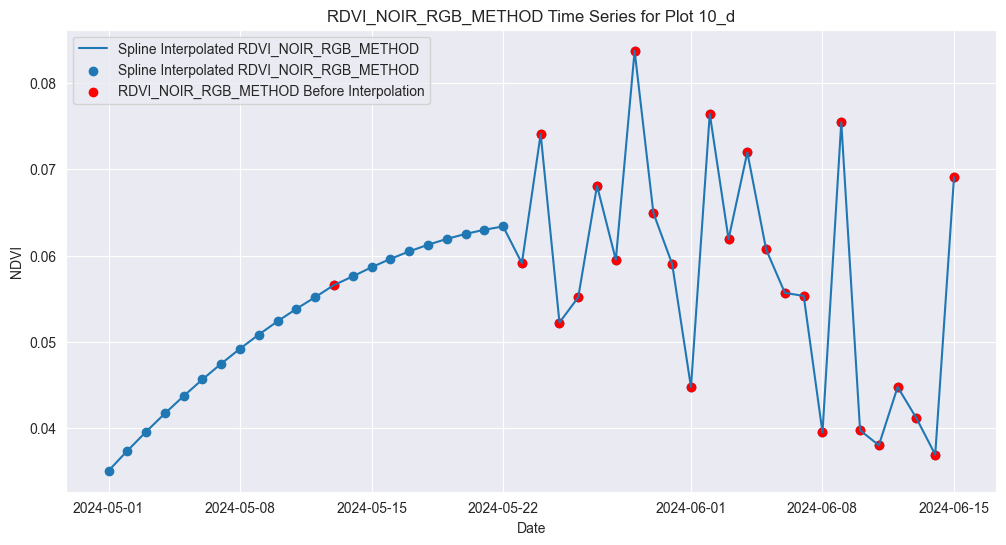

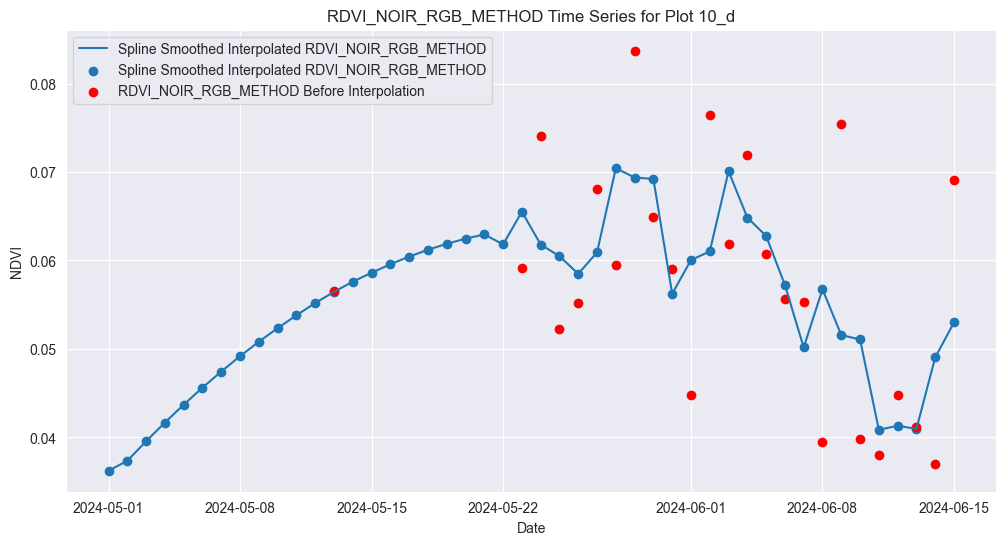

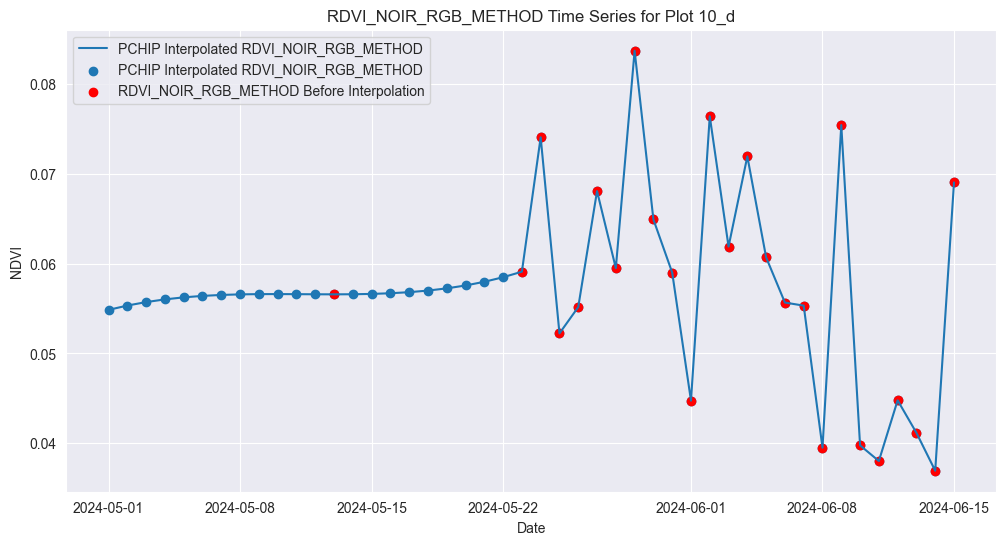

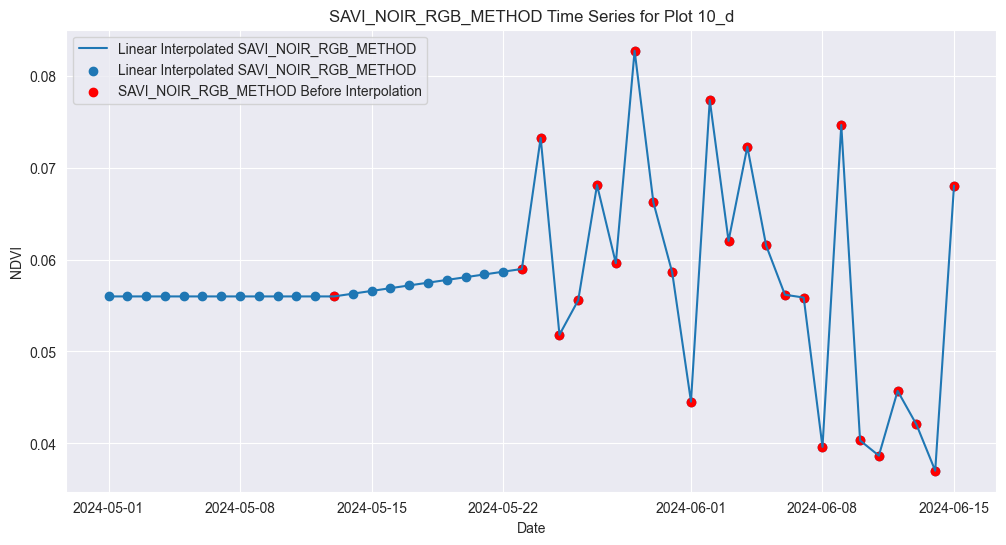

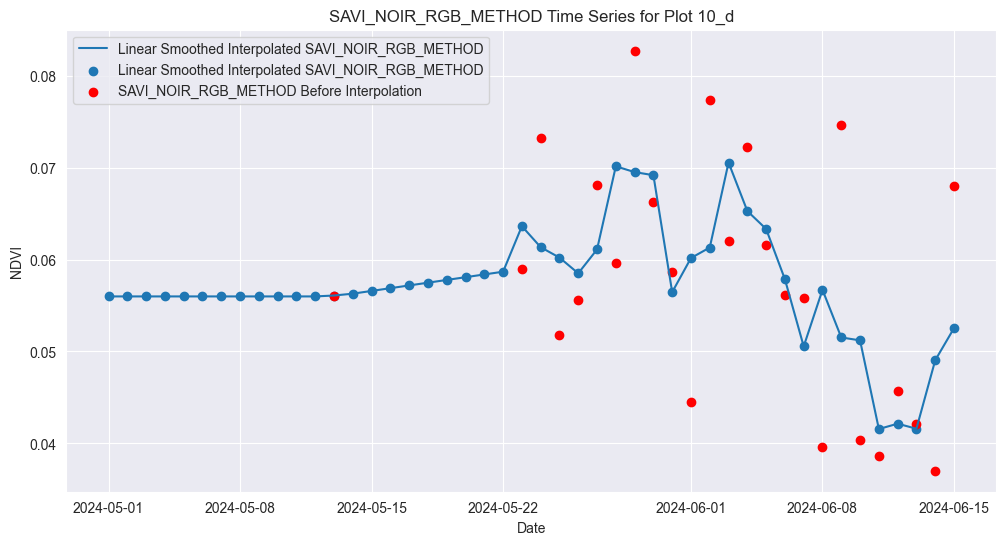

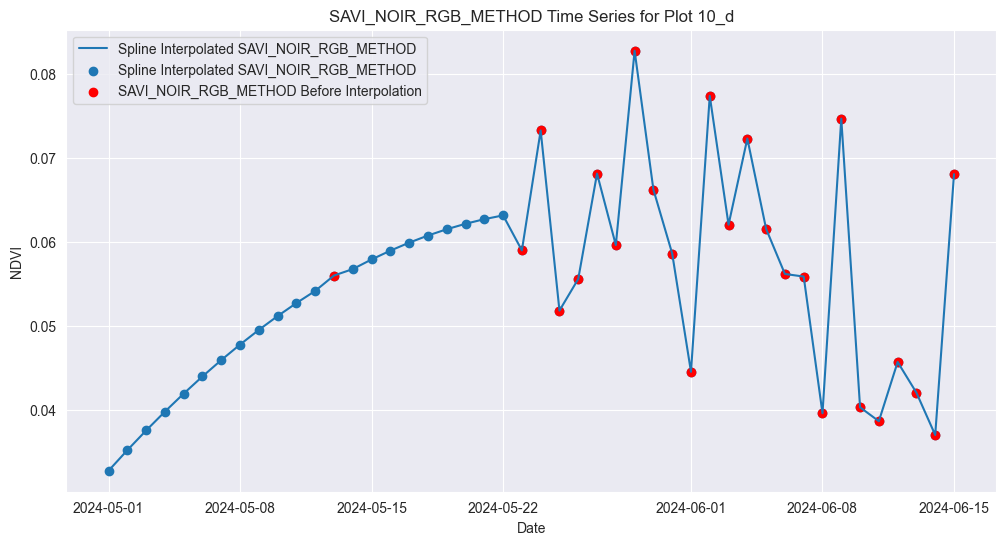

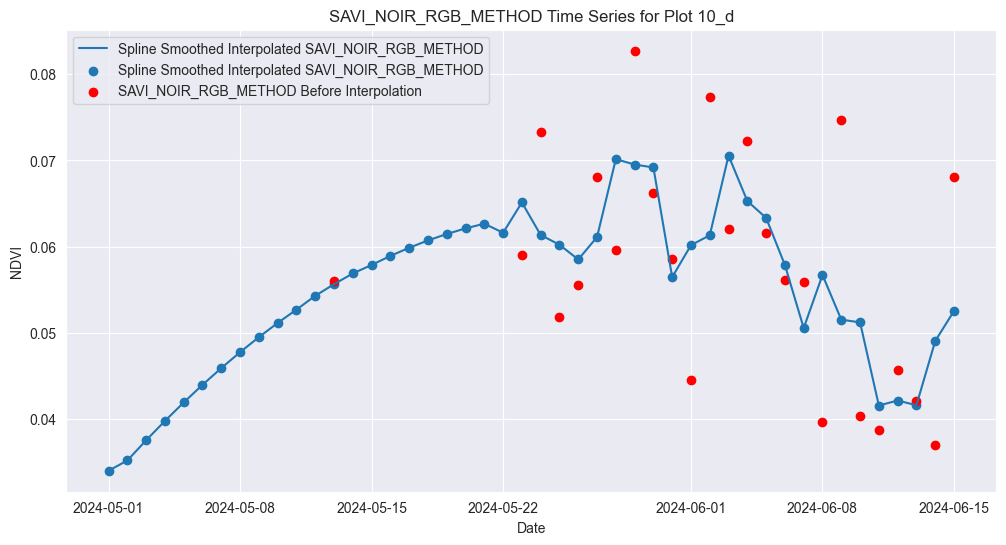

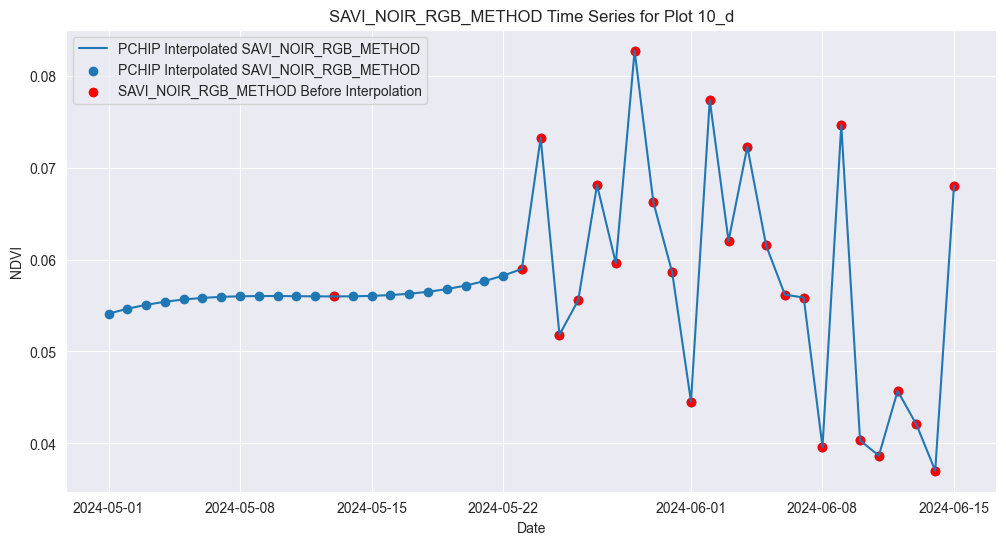

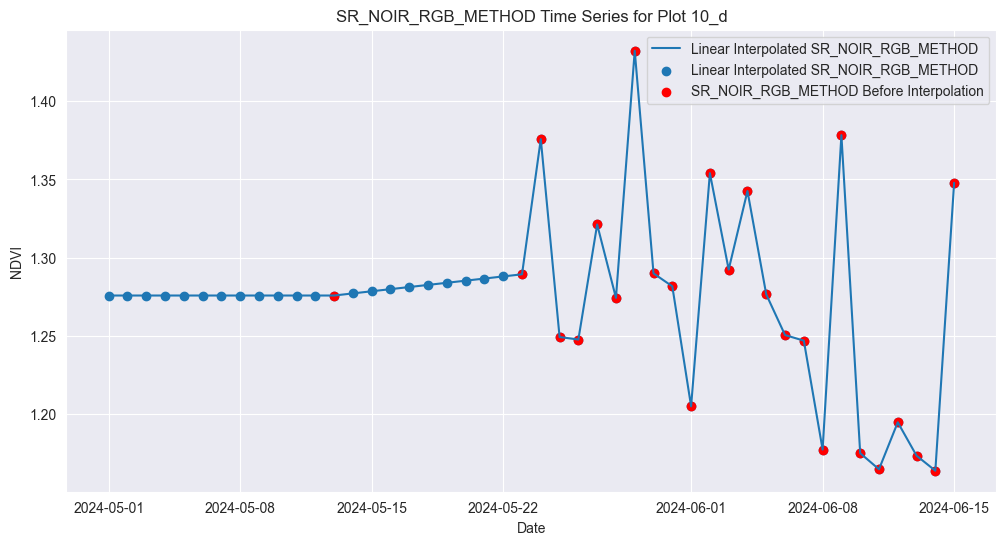

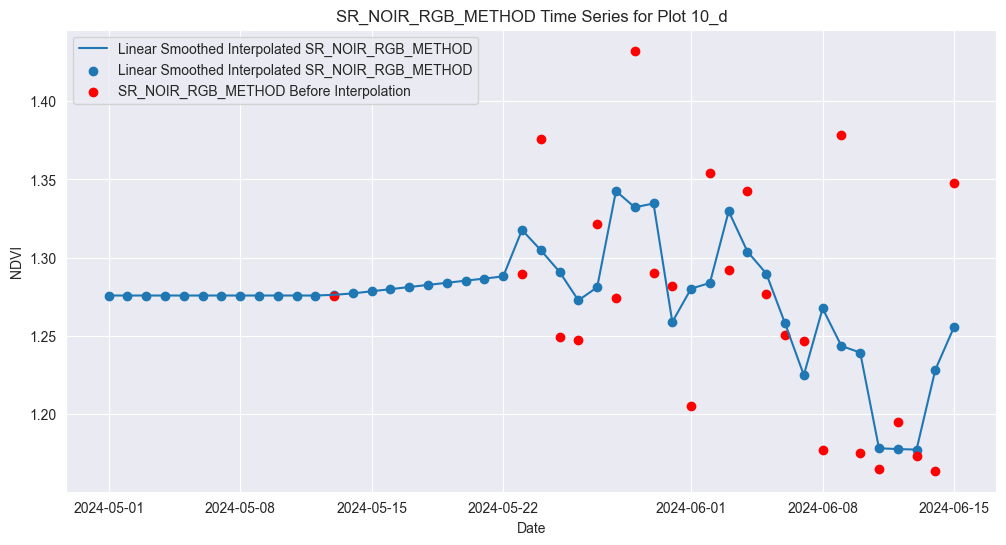

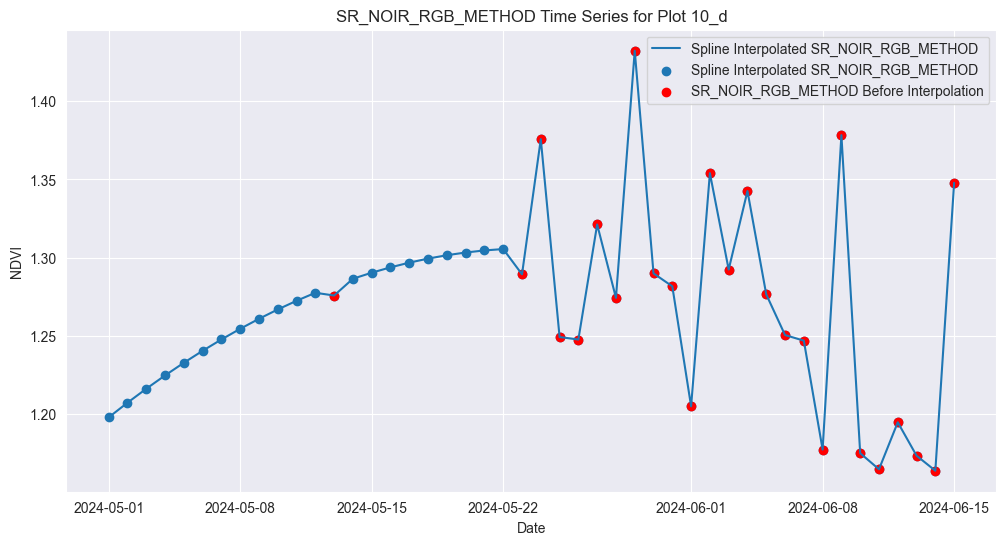

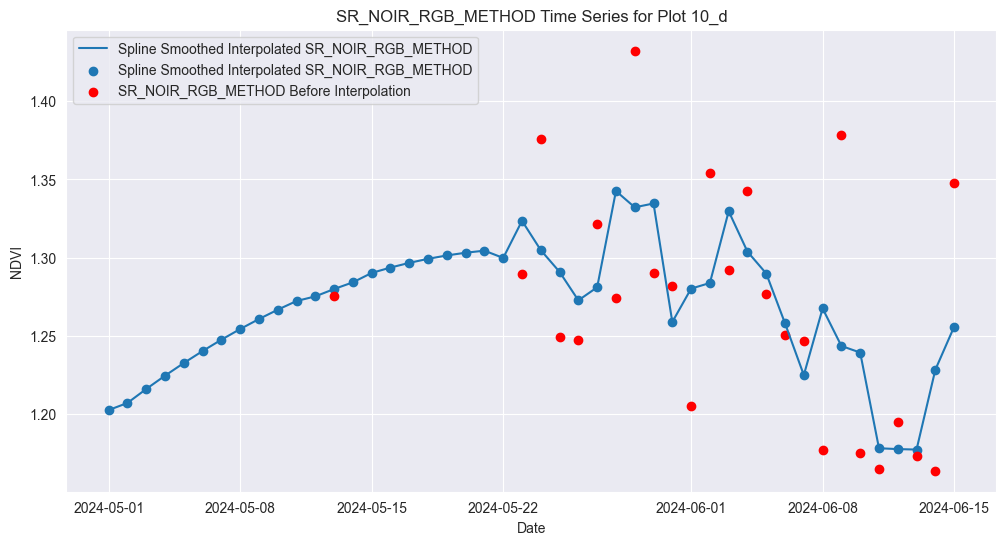

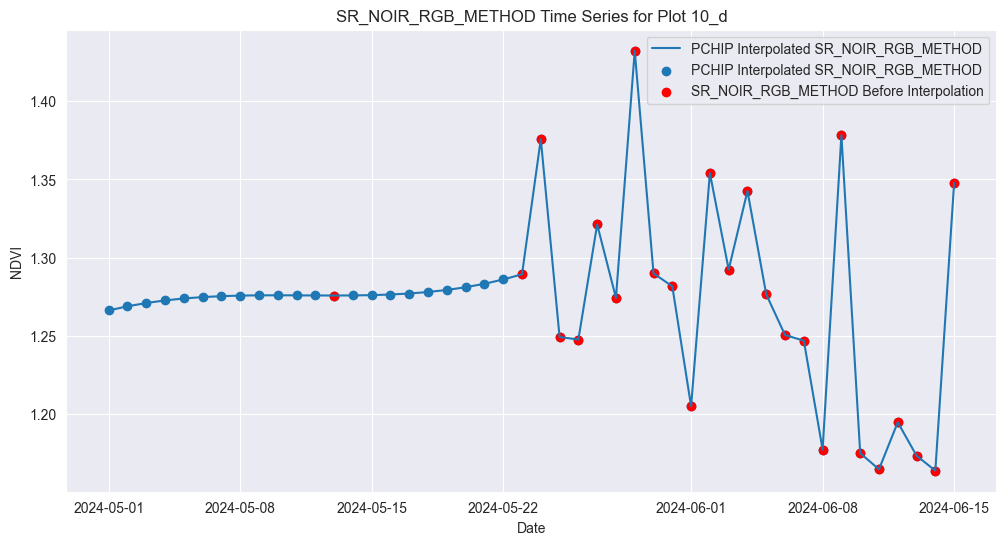

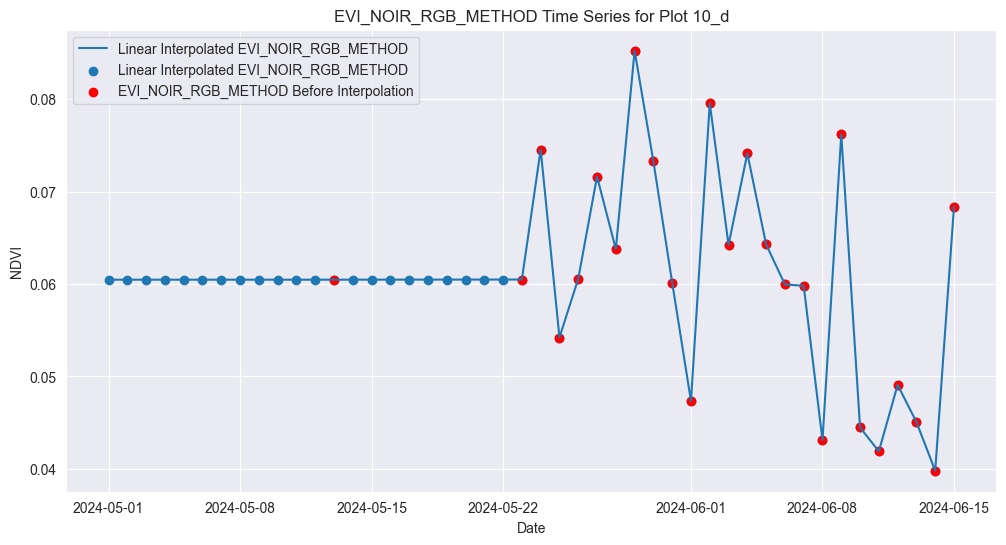

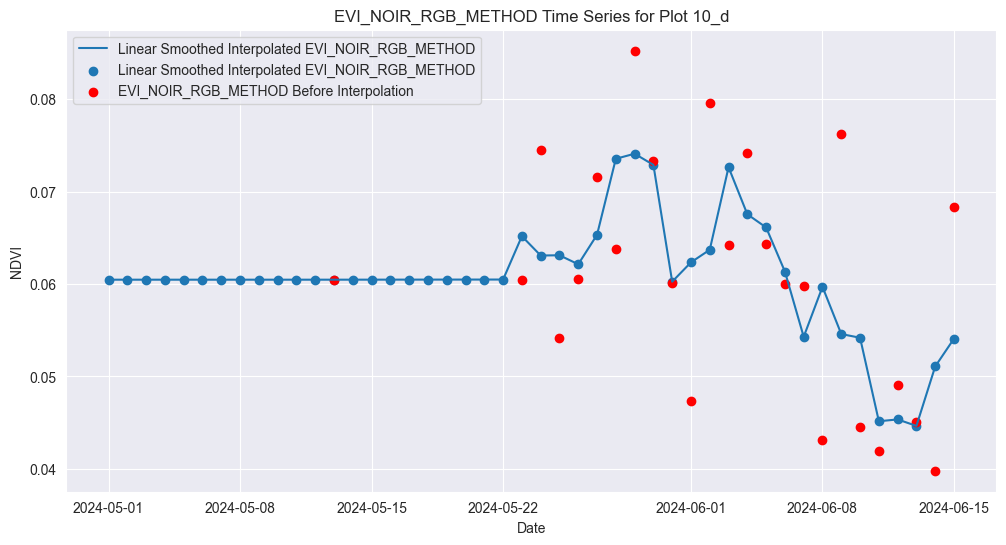

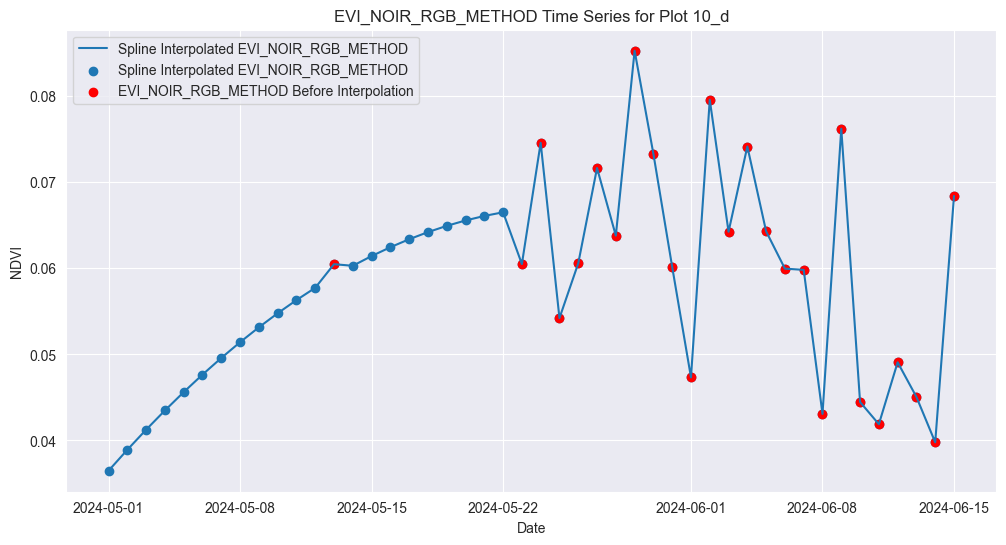

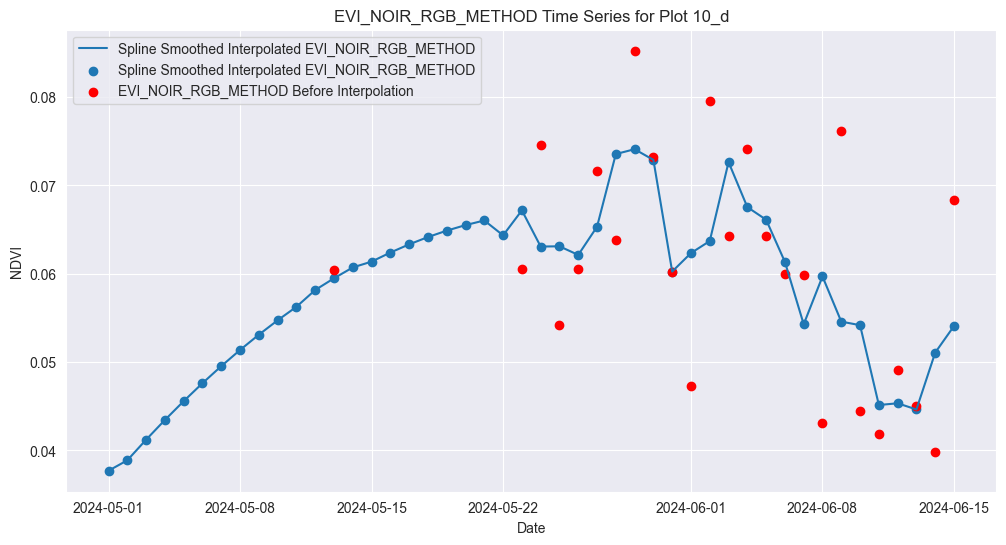

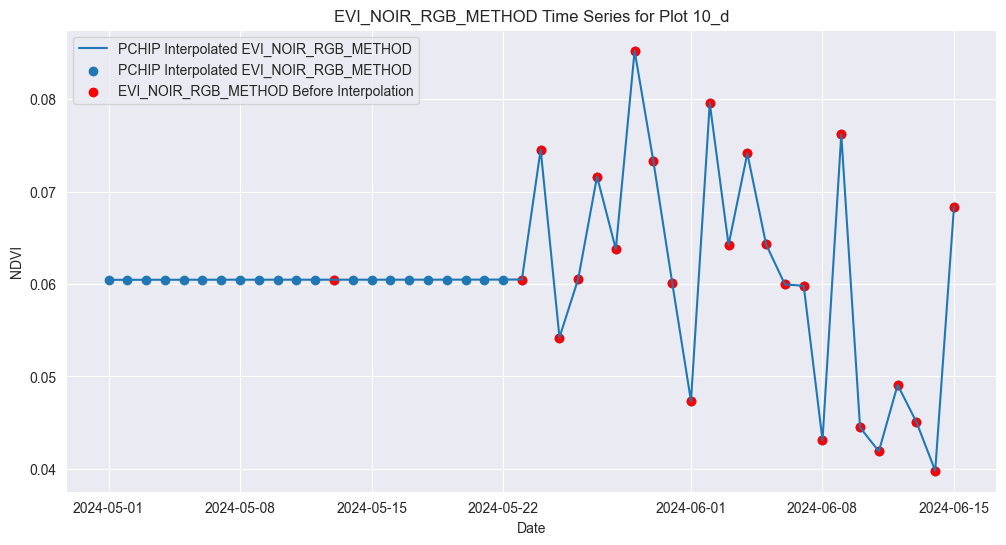

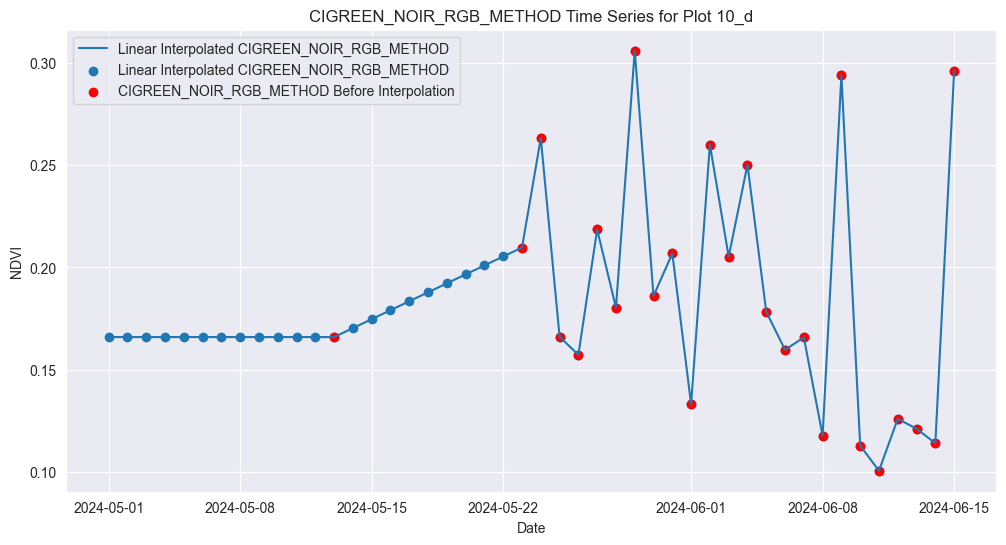

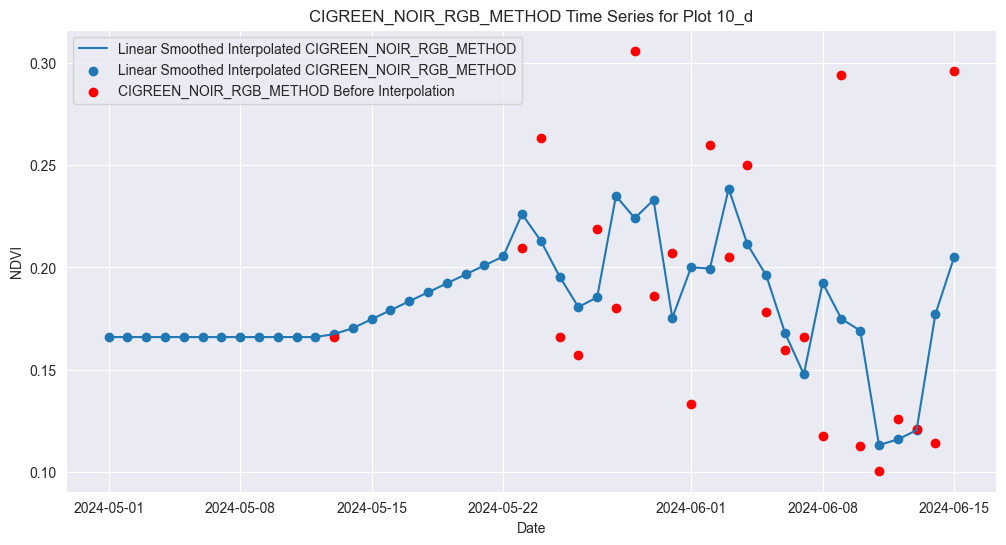

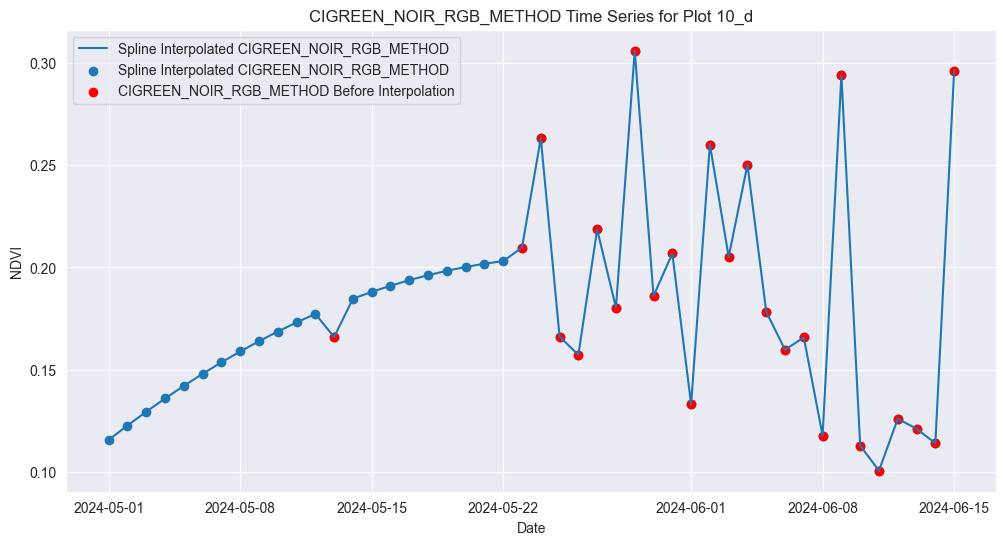

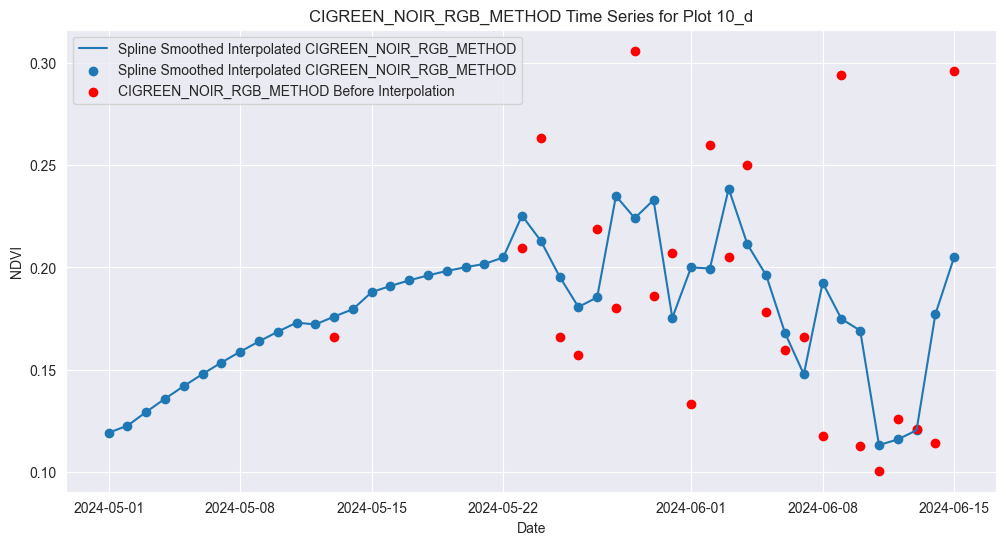

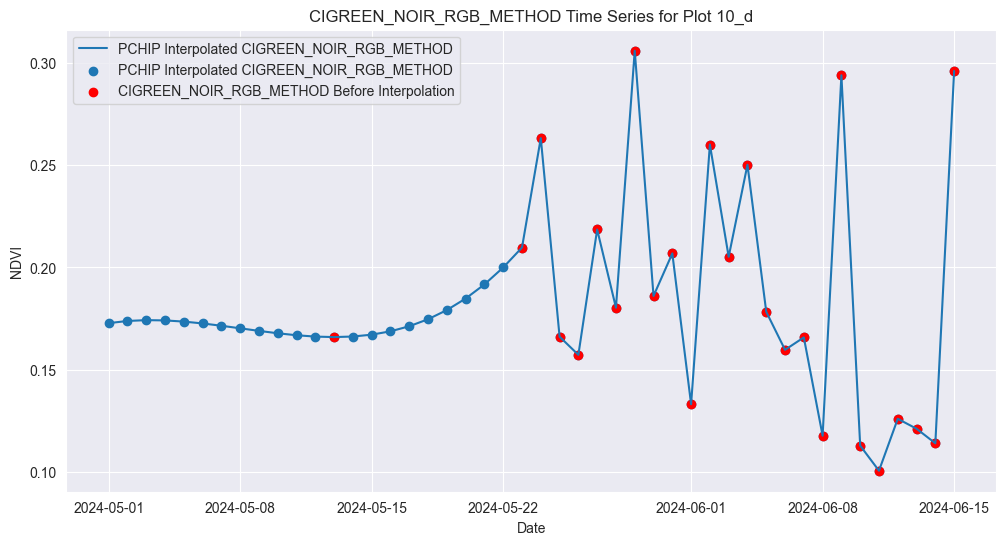

In [89]:
# Plot the NDVI over the time
plot_to_check = "10_d"
for feature in vi_features:
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Linear", interpolated_dataset=df_linear_interpolated)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Linear Smoothed", interpolated_dataset=df_linear_interpolated_and_smoothed)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Spline",
                               interpolated_dataset=df_spline_interpolated)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Spline Smoothed",
                               interpolated_dataset=df_spline_interpolated_and_smoothed)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="PCHIP",
                               interpolated_dataset=df_PCHIP_interpolated)

In [100]:
for feature in features:
    daily_corr = (
        df_linear_interpolated_and_smoothed.groupby('date')
        .apply(lambda g: g[feature].corr(g[output_variable]))
        .reset_index(name='correlation')
    )

    avg_corr = daily_corr['correlation'].mean()
    print(f"Average daily {feature.upper()}–Yield correlation: {avg_corr:.3f}")

# at 1pm
# Average daily NDVI_NOIR_RGB_METHOD–Yield correlation: 0.476
# Average daily GNDVI_NOIR_RGB_METHOD–Yield correlation: 0.466

# at 10am_mark
# Average daily NDVI_NOIR_RGB_METHOD–Yield correlation: 0.419
# Average daily GNDVI_NOIR_RGB_METHOD–Yield correlation: 0.445



Average daily NDVI_NOIR_RGB_METHOD–Yield correlation: 0.476
Average daily GNDVI_NOIR_RGB_METHOD–Yield correlation: 0.466
Average daily RDVI_NOIR_RGB_METHOD–Yield correlation: 0.455
Average daily SAVI_NOIR_RGB_METHOD–Yield correlation: 0.444
Average daily SR_NOIR_RGB_METHOD–Yield correlation: 0.452
Average daily EVI_NOIR_RGB_METHOD–Yield correlation: 0.429
Average daily CIGREEN_NOIR_RGB_METHOD–Yield correlation: 0.430
Average daily LEPTON_MEAN_TEMP–Yield correlation: -0.053
Average daily LEPTON_MIN_TEMP–Yield correlation: -0.049
Average daily LEPTON_MAX_TEMP–Yield correlation: -0.031


C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\640855743.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[feature].corr(g[output_variable]))
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_134508\640855743.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[feature].corr(g[output_variable]))
C:\Users\lochana.marasingha\AppData\Local\Temp\ipy

In [101]:
#Stratified split at plot level
#
# Get one yield per plot
plot_yields = df_linear_interpolated_and_smoothed.groupby('plot_id')[output_variable].first().reset_index()
# Create yield bins
plot_yields['yield_bin'] = pd.cut(plot_yields[output_variable], bins=5, labels=False)

from sklearn.model_selection import StratifiedShuffleSplit

train_plot_ids = []
test_plot_ids = []
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(plot_yields, plot_yields['yield_bin']):
    train_plot_ids = plot_yields.iloc[train_idx]['plot_id']
    test_plot_ids = plot_yields.iloc[test_idx]['plot_id']

In [102]:
plot_yields

,plot_id,GYLD_kg_m3,yield_bin
0,10_d,0.8499,0
1,10_w,1.1218,2
2,11_d,1.0524,1
3,11_w,1.5795,4
4,12_d,0.9493,1
5,12_w,1.4828,4
6,13_d,1.4573,3
7,13_w,1.0088,1
8,14_d,1.1822,2
9,14_w,0.8068,0


In [103]:
train_df = df_linear_interpolated_and_smoothed[df_linear_interpolated_and_smoothed['plot_id'].isin(train_plot_ids)]
test_df  = df_linear_interpolated_and_smoothed[df_linear_interpolated_and_smoothed['plot_id'].isin(test_plot_ids)]

test_df

,date,plot_id,ndvi_noir_rgb_method,gndvi_noir_rgb_method,rdvi_noir_rgb_method,savi_noir_rgb_method,sr_noir_rgb_method,evi_noir_rgb_method,cigreen_noir_rgb_method,lepton_mean_temp,lepton_min_temp,lepton_max_temp,GYLD_kg_m3
368,2024-05-01,14_d,0.128776,0.084131,0.064189,0.064114,1.299374,0.069698,0.186082,24.460153,20.674524,30.479355,1.1822
369,2024-05-02,14_d,0.134681,0.088004,0.067268,0.067235,1.315330,0.073014,0.195431,34.736689,33.169168,36.319429,1.1822
370,2024-05-03,14_d,0.172136,0.115779,0.089897,0.091048,1.427891,0.098036,0.267639,17.662139,16.705180,19.636209,1.1822
371,2024-05-04,14_d,0.191023,0.129382,0.102500,0.104627,1.486614,0.112959,0.303813,18.804566,18.060429,19.805159,1.1822
372,2024-05-05,14_d,0.199484,0.135434,0.108215,0.110797,1.513332,0.119526,0.320111,NaN,NaN,NaN,1.1822
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1927,2024-06-11,7_d,0.068298,0.042436,0.037006,0.037879,1.155274,0.040588,0.096670,NaN,NaN,NaN,0.7836
1928,2024-06-12,7_d,0.059124,0.035109,0.032315,0.033139,1.133640,0.035269,0.080093,NaN,NaN,NaN,0.7836
1929,2024-06-13,7_d,0.051916,0.030645,0.028269,0.028957,1.115460,0.030754,0.069088,NaN,NaN,NaN,0.7836
1930,2024-06-14,7_d,0.063130,0.047917,0.033921,0.034598,1.141022,0.036316,0.107841,NaN,NaN,NaN,0.7836


In [104]:
print(set(train_df['plot_id']).intersection(set(test_df['plot_id'])))  # should be empty


set()


In [106]:

num_na_rows = train_df.isna().any(axis=1).sum()
print(f"train_df Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df.isna().any(axis=1).sum()
print(f"train_df Rows with at least one NaN: {num_na_rows}")
test_df

train_df Rows with at least one NaN: 1084
train_df Rows with at least one NaN: 354


,date,plot_id,ndvi_noir_rgb_method,gndvi_noir_rgb_method,rdvi_noir_rgb_method,savi_noir_rgb_method,sr_noir_rgb_method,evi_noir_rgb_method,cigreen_noir_rgb_method,lepton_mean_temp,lepton_min_temp,lepton_max_temp,GYLD_kg_m3
368,2024-05-01,14_d,0.128776,0.084131,0.064189,0.064114,1.299374,0.069698,0.186082,24.460153,20.674524,30.479355,1.1822
369,2024-05-02,14_d,0.134681,0.088004,0.067268,0.067235,1.315330,0.073014,0.195431,34.736689,33.169168,36.319429,1.1822
370,2024-05-03,14_d,0.172136,0.115779,0.089897,0.091048,1.427891,0.098036,0.267639,17.662139,16.705180,19.636209,1.1822
371,2024-05-04,14_d,0.191023,0.129382,0.102500,0.104627,1.486614,0.112959,0.303813,18.804566,18.060429,19.805159,1.1822
372,2024-05-05,14_d,0.199484,0.135434,0.108215,0.110797,1.513332,0.119526,0.320111,NaN,NaN,NaN,1.1822
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1927,2024-06-11,7_d,0.068298,0.042436,0.037006,0.037879,1.155274,0.040588,0.096670,NaN,NaN,NaN,0.7836
1928,2024-06-12,7_d,0.059124,0.035109,0.032315,0.033139,1.133640,0.035269,0.080093,NaN,NaN,NaN,0.7836
1929,2024-06-13,7_d,0.051916,0.030645,0.028269,0.028957,1.115460,0.030754,0.069088,NaN,NaN,NaN,0.7836
1930,2024-06-14,7_d,0.063130,0.047917,0.033921,0.034598,1.141022,0.036316,0.107841,NaN,NaN,NaN,0.7836


In [107]:
with pd.ExcelWriter("data/stratified_train_test_datasets_v2.xlsx", engine="openpyxl") as writer:
    train_df.to_excel(writer, sheet_name="Train", index=False)
    test_df.to_excel(writer, sheet_name="Test", index=False)
